In [55]:
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6

import numpy as np
import matplotlib.pyplot as plt
import copy

import sys

#from ham_creation import create_hex_ham
from lat_creation import get_positions_graphene
from core import DOS_sparse, frequency_analysis, load_data, load_data_dict, frequency_analysis_dict
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# Benchmarking
from time import time
from datetime import timedelta

hbar = 0.6582


# Matplotlib stuff
plt.rcParams.update({'font.size': 11})  # Match REVTeX default 10pt
plt.rcParams['pdf.fonttype'] = 42  # Save text as TrueType (editable) instead of paths
plt.rcParams['ps.fonttype'] = 42   # Same for PostScript
plt.rcParams['text.usetex'] = True  # Keep LaTeX rendering
plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams.update({
    # TEXT OPTIONS
    'font.size': 11,              # Tamaño base general (afecta a textos libres)
    'figure.titlesize': 12,       # Título principal de la figura (suptitle)
    'axes.titlesize': 11,         # Título de cada gráfico (title)
    'axes.labelsize': 11,         # Etiquetas de los ejes (xlabel e ylabel)
    'xtick.labelsize': 9,        # Números/marcas del eje X
    'ytick.labelsize': 9,        # Números/marcas del eje Y
    'legend.fontsize': 8,        # Texto de los elementos de la leyenda
    'legend.title_fontsize': 10,   # Título de la leyenda

    # PLOT OPTIONS
    'lines.linewidth': 2,         # Grosor de las líneas de los gráficos
    'lines.markersize': 1.5,       # Tamaño de los puntos/marcadores
    'lines.markeredgewidth': 0.0, # Grosor del borde de los marcadores

    # GRID
    #'grid.linewidth': 0.8,           # Grosor de las líneas de la cuadrícula de fondo

    # TICKS 
    'xtick.major.size': 4,           # Qué tan largas son las marcas del eje X
    'xtick.major.width': 0.6,        # Qué tan gordas son las marcas del eje X
    'ytick.major.size': 4,           # Qué tan largas son las marcas del eje Y
    'ytick.major.width': 0.6,        # Qué tan gordas son las marcas del eje Y
    'xtick.direction' : 'in',
    'ytick.direction' : 'in',
})


out_loc = r"D:\Downloads\NEQ"


In [56]:
# ------------------------------------------------------------------------------
#### PARAMETERS OF THE MODEL
## PHYSICAL
# Type of light               
modifier_id = 'circle_packed'
# Hamiltonian type
type_ham = 'basic'
# Parameters of the ham (only read if hbn)
ham_params = 0.5
# Energy in pulse                        
E = 1.0
# Temperature                       
Temp = 1e-9
# Chemical potential
mu = 0.00
# Intensity param     (no units)
gamma = 0.030

## SIMULATION
# Size of hamiltonian (2**N_pot)
N_pot = 20
N = 2**N_pot
# Amount of periods to be simulated
n_periods = 8
# Simulation steps per period
steps_per_T = 1000
# Amount of measures per period
meas_per_T = 16

# Amount of random vectors used in calculation
N_random_vector = 10
# Momenta
M = int(np.sqrt(N))

## CALCULATED PARAMS
# ------------------------------------------------------------------------------
####  Defining a hamiltonian (own)

# Parameters of the laser
w = E/hbar
T = 2*np.pi/w    
t_vec = np.linspace(0,n_periods*T , steps_per_T*n_periods)   
# Amount of half multiples of E where the occupation is obtained
hE_reps = 2
# Broadening in the energies
broad = 8.5*np.pi/M
N_measures = meas_per_T*n_periods
t_vec_measures = np.linspace(0, n_periods*T, N_measures)

# Print of parameters to check results
print('PARAMETERS OF CALCULATION')
print(f'Type of hamiltonian is {type_ham}')
print(f'Hamiltonian parameter is {ham_params}')
print(f'Type of light is {modifier_id}')
print(f'# of atoms: {N}')
print(f'# of moments: {M}')
print(f'Energy: {E} eV')
print(f'Intensity param: {gamma}')
print(f'Temperature: {Temp} K')
print(f'Chem potential: {mu} eV')
print(f'# of Random Vectors: {N_random_vector}')
print(f'# of periods: {n_periods}')
print(f'steps/period: {steps_per_T}')
print(f'# measures/T: {meas_per_T}')


# Names of file and info on graphs
fig_title_info = f'$N={{{2**N_pot}}}$, $\\hbar\\omega={E}$ eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}, M={M}\n'
extra_text = f'Light: {modifier_id}\n$\\delta E={broad:.3f}$\n# Rand Vecs: {N_random_vector}\nMeasures/T={meas_per_T}\nSteps/T={steps_per_T}'

#fig_title_info=f'Light: {modifier_id},$N={{{2**N_pot}}}$, $\\hbar\\omega={E}$ eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}\n$M={M}$, $R={N_random_vector}$, Meas/T={meas_per_T}, $St/T={steps_per_T}$'

EF_list, n_E_list, dos_list, dosn_list = load_data(modifier_id, N_pot, E, Temp, mu, gamma, 
                        M, N_random_vector, n_periods, meas_per_T, steps_per_T, type_ham, ham_params, R=None, out_file_loc=out_loc)
            
# Remaking the graphs of oscillations in time
hE_list = [hE*E/2 for hE in range(-hE_reps, hE_reps+1)]


PARAMETERS OF CALCULATION
Type of hamiltonian is basic
Hamiltonian parameter is 0.5
Type of light is circle_packed
# of atoms: 1048576
# of moments: 1024
Energy: 1.0 eV
Intensity param: 0.03
Temperature: 1e-09 K
Chem potential: 0.0 eV
# of Random Vectors: 10
# of periods: 8
steps/period: 1000
# measures/T: 16
8/10 calculations finished! Loading 8 results...


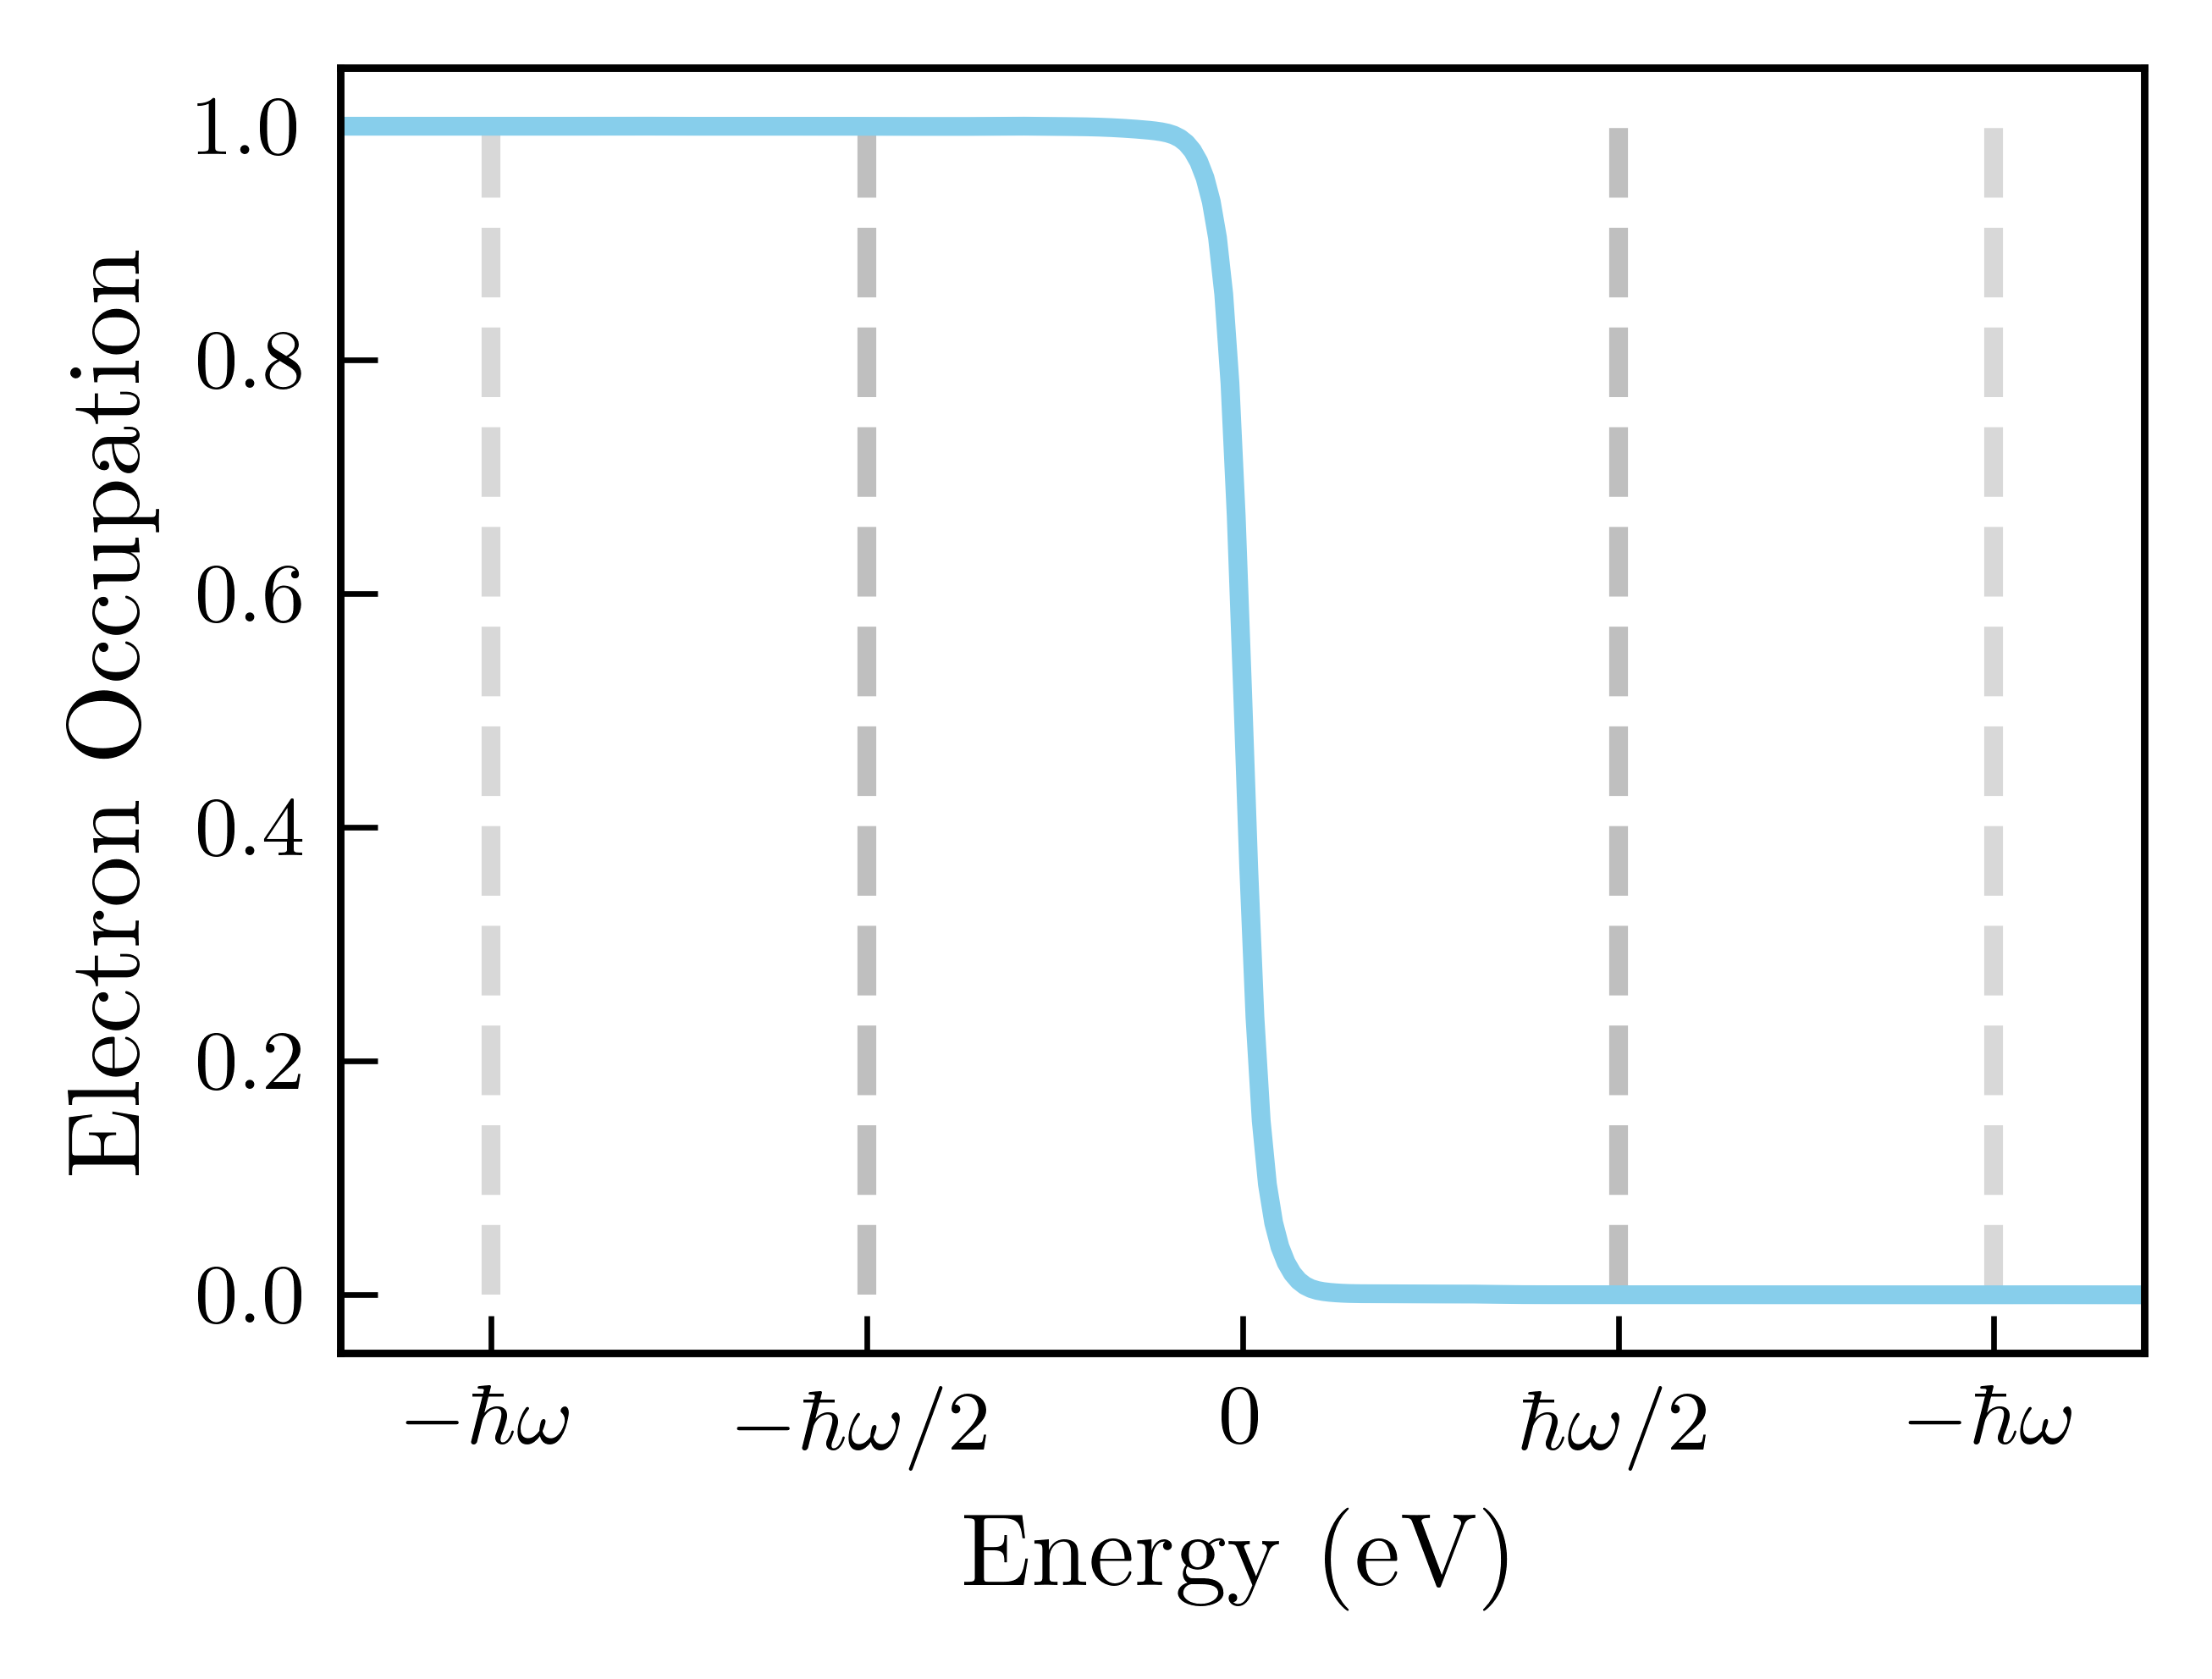

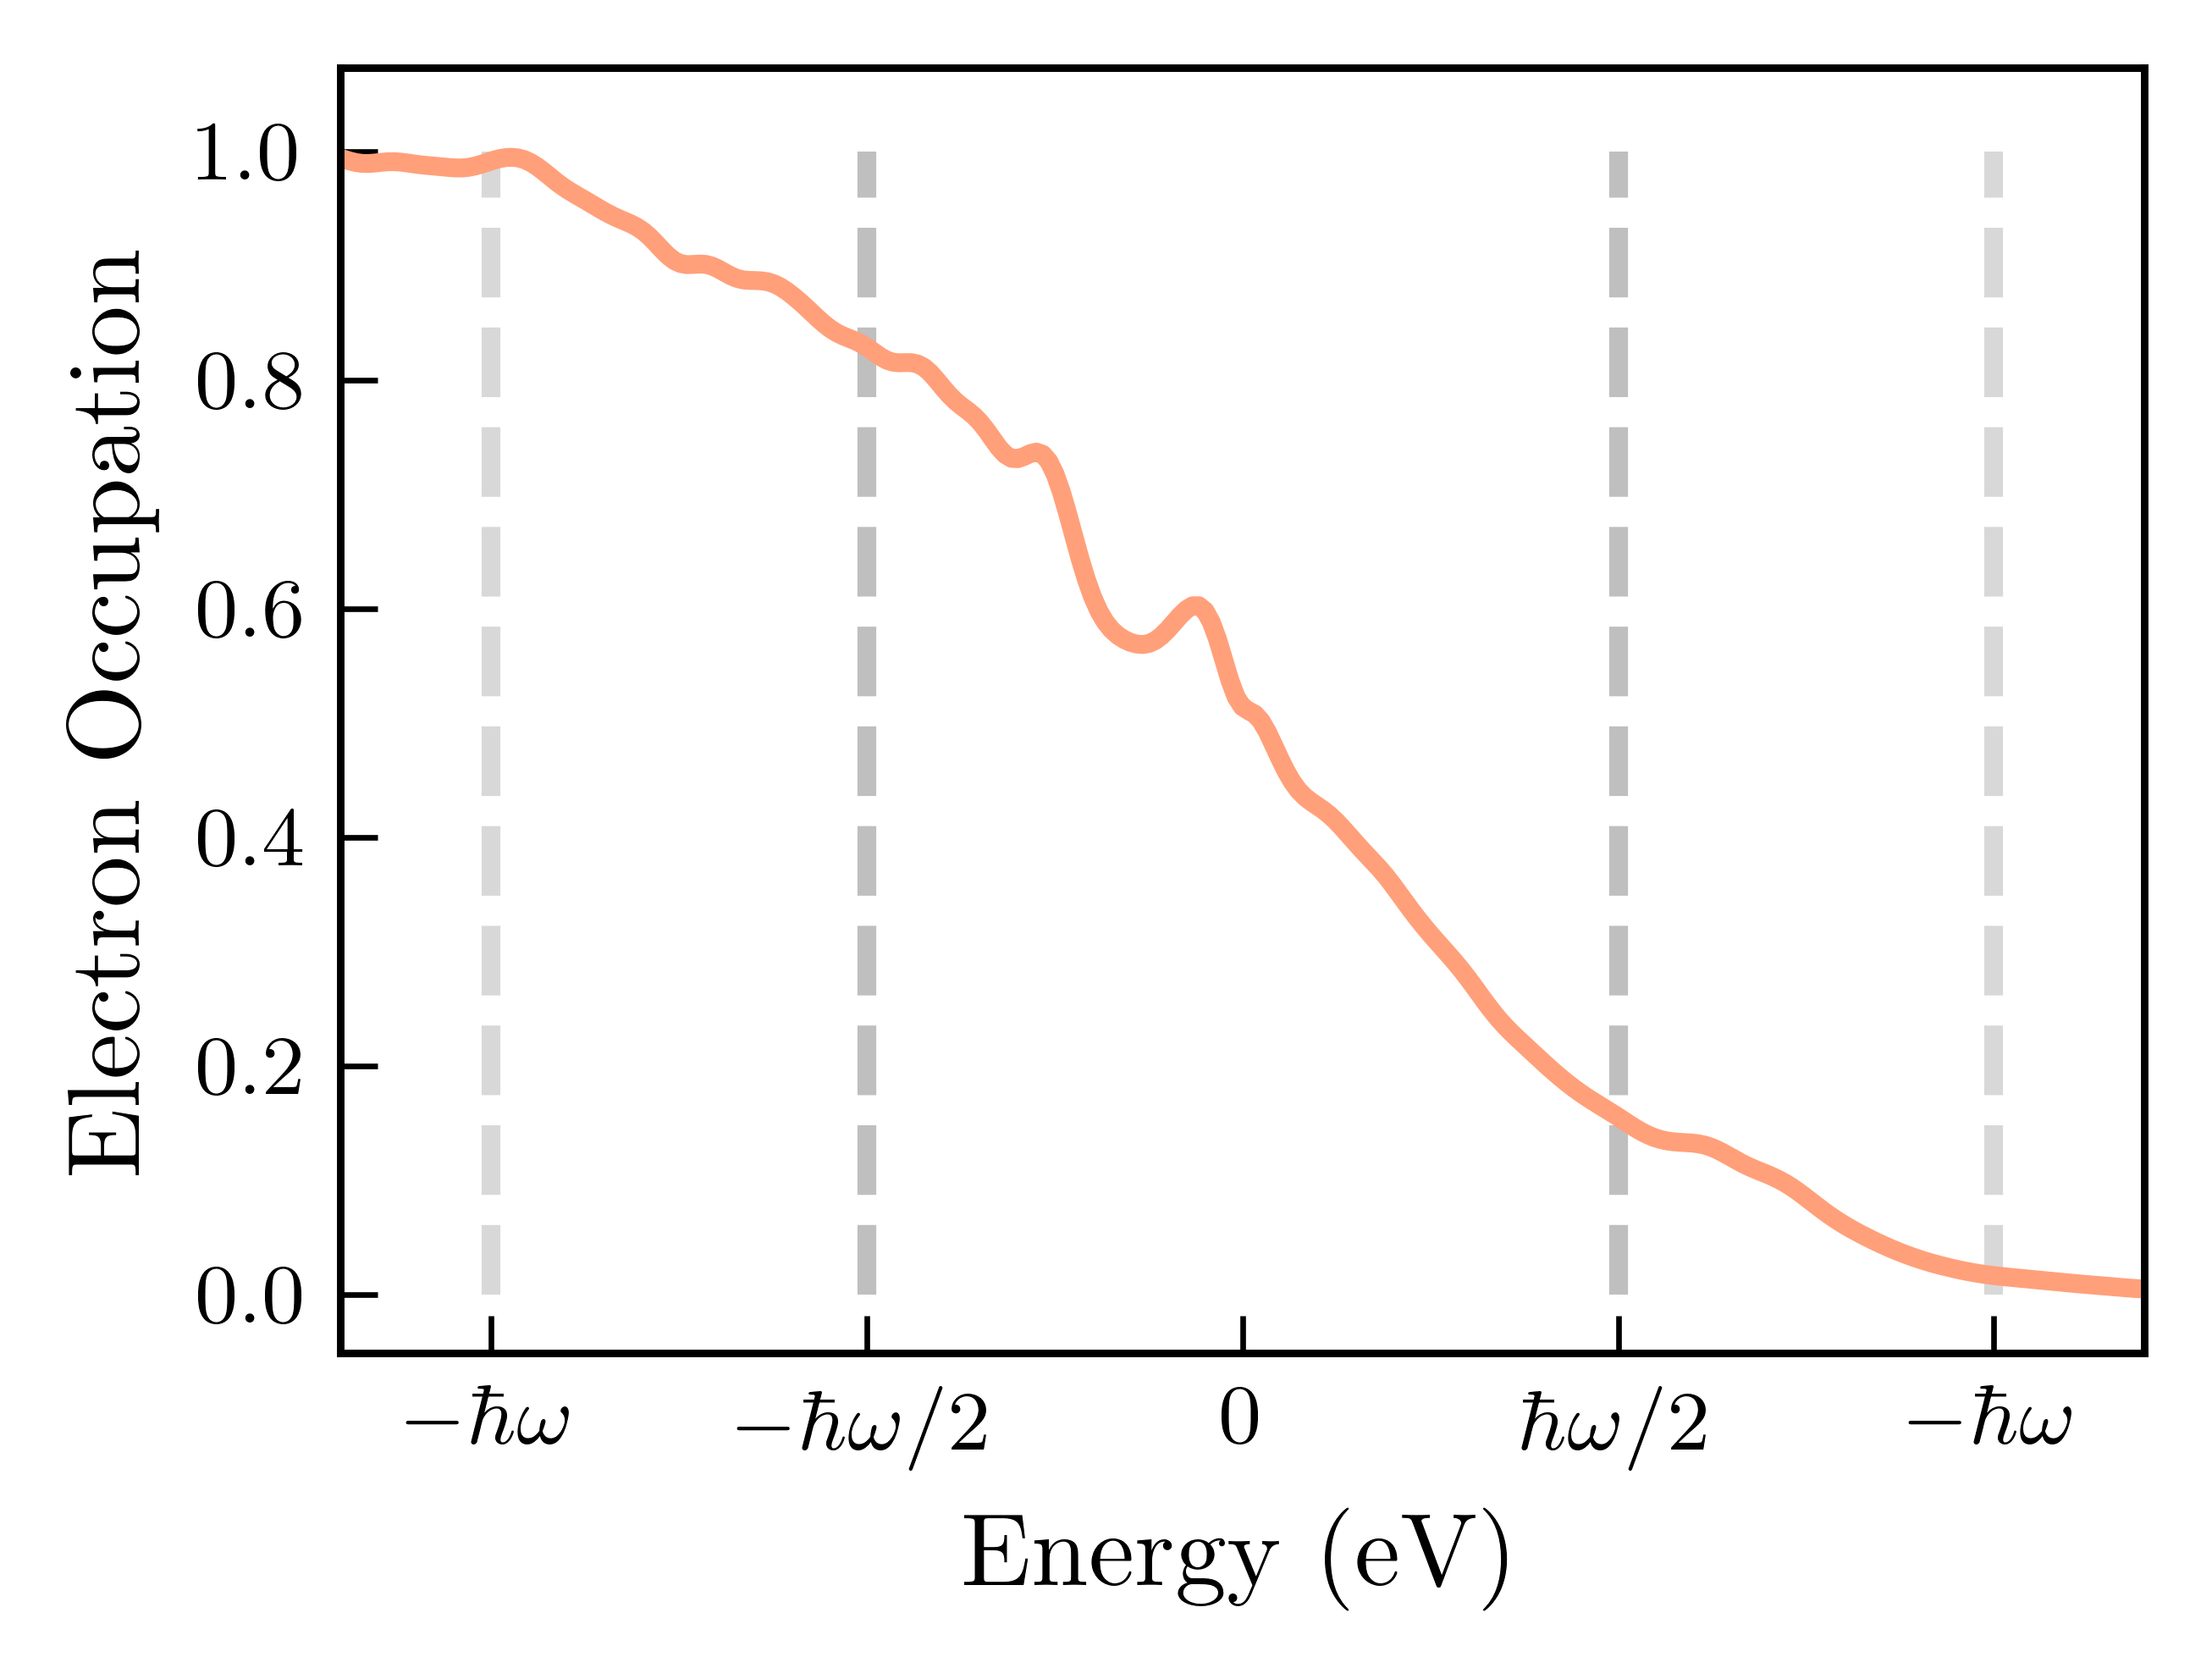

In [57]:
# TWO TIMES FOR THE COMPARISON GRAPH
min_e, max_e = -1.2*E, 1.2*E
colors = ['skyblue', 'lightsalmon']
for i, fr in enumerate([0,4*8]):
    fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
    ax.plot(EF_list[fr,:], n_E_list[fr,:], color=colors[i])
    #ax.legend()
    #cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Electron Occupation')
    ax.set_xlim(min_e, max_e)
    ax.vlines([-E, E], 0, 1, color='grey', ls='--', alpha=0.3, zorder=1)
    ax.vlines([ -E/2, E/2], 0, 1, color='grey', ls='--', alpha=0.5, zorder=1)
    #ax.vlines([0], 0, 1, color='grey', ls='--', alpha=0.8, zorder=1)
    #ax.set_xticks([-E, -E/2, 0, E/2, E], labels=['$-\\hbar \\omega$', '$-\\hbar \\omega/2$', '$0$', '$\\hbar \\omega/2$', '$-\\hbar \\omega$'])
    ax.set_xticks([-E, -E/2, 0, E/2, E], labels=['$-\\hbar \\omega$', '$-\\hbar \\omega/2$', '$0$', '$\\hbar \\omega/2$', '$-\\hbar \\omega$'])
    #ax.text(min_e + 0.5*E, 0.2, extra_text, bbox=props)
    fig.savefig(f'Graphs/neq_show{fr}.png')
    plt.show()



In [58]:
# Loading the data for the graphs of N(T) and Fourier
modifier_id = 'circln'
type_ham = 'basic'
ham_params = 0.5
E = 0.5
Temp = 1e-9
mu = 0.01
N_pot = 20
M = int(np.sqrt(2**N_pot))
R = 5
steps_per_T = 1000

res0 = {'modifier_id': modifier_id,
        'type_ham': 'basic',
        'ham_params': ham_params,  
        'hw' : E,                       
        'Temp' :  Temp,
        'mu' : mu,                 
        'N_pot' : N_pot,
        'steps_per_T' : steps_per_T,
        'n_periods' : 100,
        'meas_per_T' : 4,
        'N_random_vector' : R,
        'M' : M,
        'gamma' : 0.000}

res1 = {'modifier_id': modifier_id,
        'type_ham': 'basic',
        'ham_params': ham_params,  
        'hw' : E,                       
        'Temp' :  Temp,
        'mu' : mu,                 
        'N_pot' : N_pot,
        'steps_per_T' : steps_per_T,
        'n_periods' : 200,
        'meas_per_T' : 8,
        'N_random_vector' : R,
        'M' : M,
        'gamma' : 0.005}

res2 = {'modifier_id': modifier_id,
        'type_ham': 'basic',
        'ham_params': ham_params,  
        'hw' : E,                       
        'Temp' :  Temp,
        'mu' : mu,                 
        'N_pot' : N_pot,
        'steps_per_T' : steps_per_T,
        'n_periods' : 200,
        'meas_per_T' : 8,
        'N_random_vector' : R,
        'M' : M,
        'gamma' : 0.010}

res3 = {'modifier_id': modifier_id,
        'type_ham': 'basic',
        'ham_params': ham_params,  
        'hw' : E,                       
        'Temp' :  Temp,
        'mu' : mu,                 
        'N_pot' : N_pot,
        'steps_per_T' : steps_per_T,
        'n_periods' : 150,
        'meas_per_T' : 8,
        'N_random_vector' : R,
        'M' : M,
        'gamma' : 0.015}


list_res = [res0, res1, res2, res3]
for res in list_res:
    res['w'] = res['hw']/hbar
    res['T'] = 2*np.pi/res['w']    
    res['t_vec'] = np.linspace(0,res['n_periods']*res['T'] , res['steps_per_T']*res['n_periods'])   
    res['t_vec_measures'] = np.linspace(0, res['n_periods']*res['T'], res['meas_per_T']*res['n_periods'])


# Loading data and performing Fourier analyisis
for res in list_res:
        load_data_dict(res, out_file_loc=out_loc)
        frequency_analysis_dict(res)
        

5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...


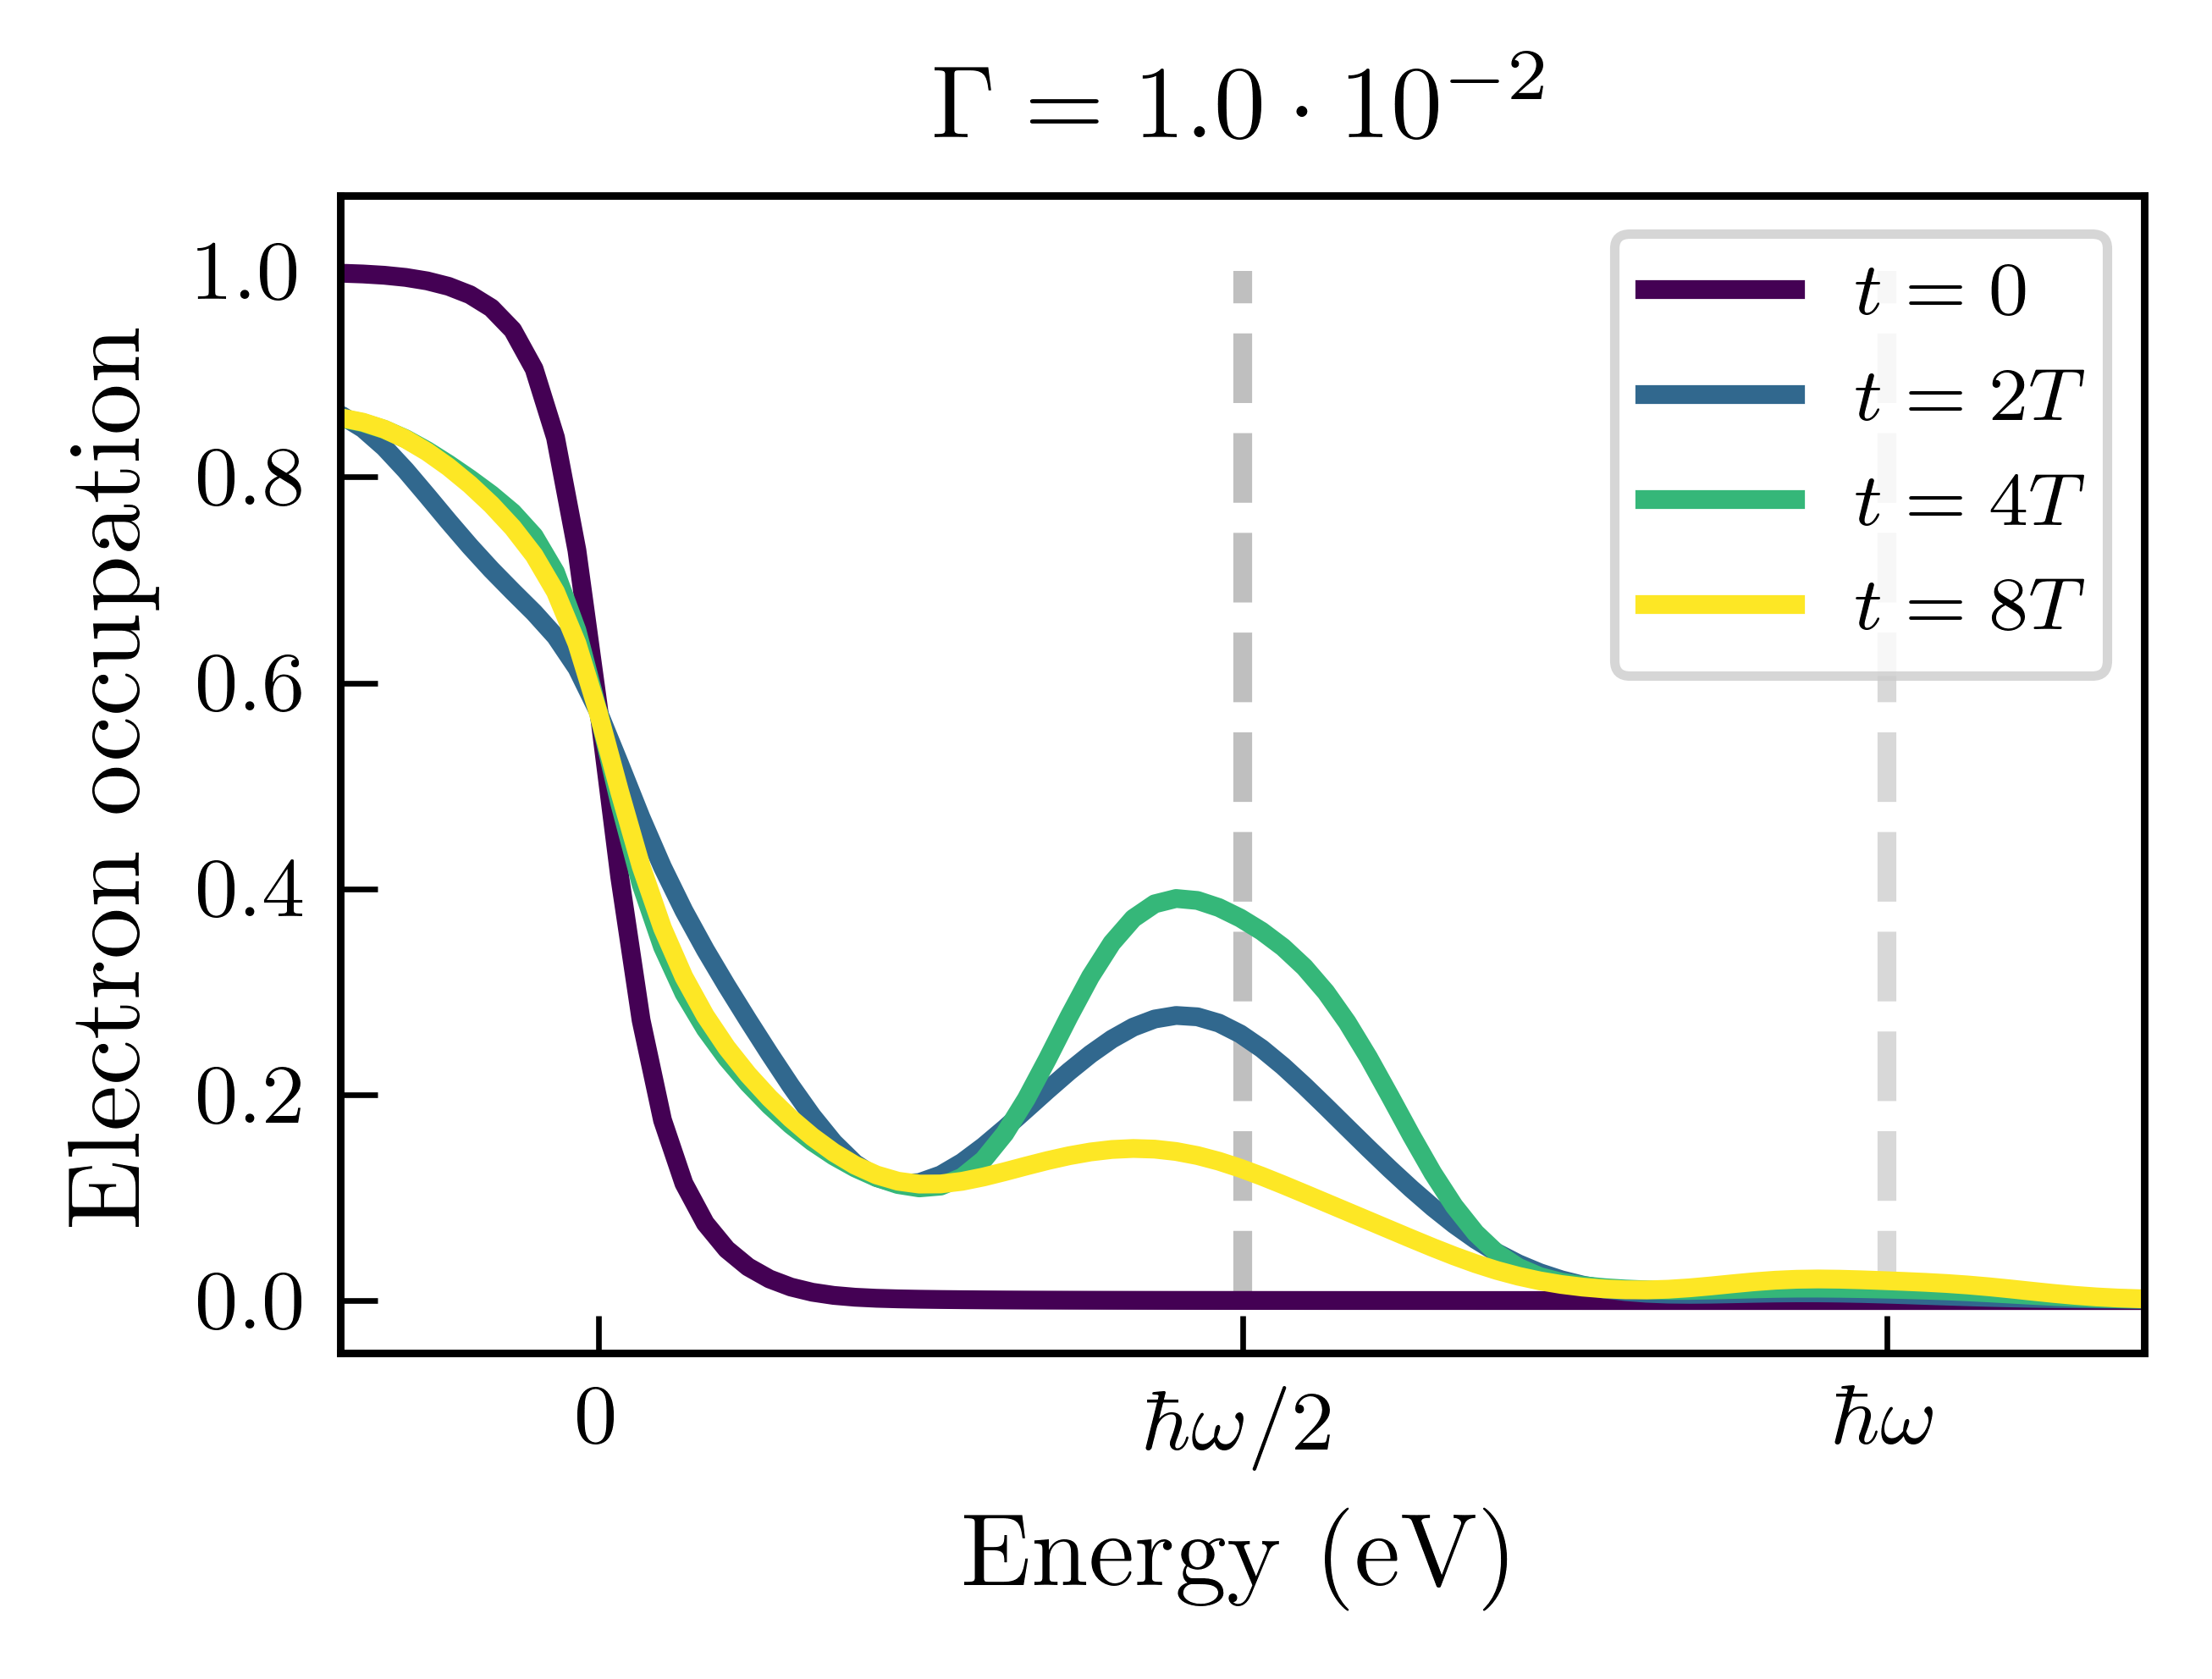

In [59]:
time_inds = [2, 4, 8]
E = 0.5
time_moments = [t_ind*res2['meas_per_T'] for t_ind in time_inds]
labels_list = [f'$t = {t_ind}T$' for t_ind in time_inds]

cmap = plt.cm.viridis 
norm = Normalize(vmin=0, vmax=len(time_moments))
min_e, max_e = -1.2*E, 1.2*E
hw_lines_step = 0.5*E
hw_hlines = [i for i in [hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
hw_hlines += [i for i in [-hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]


fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
ax.plot(res0['EF_list'][0,:], res0['n_E_list'][0,:], color=cmap(norm(0)), label='$t=0$')
for i, ind in enumerate(time_moments):
    ax.plot(res2['EF_list'][ind,:], res2['n_E_list'][ind,:], color=cmap(norm(i+1)), label=labels_list[i])

ax.set_xlim(min_e, max_e)
ax.vlines([-E, E], 0, 1, color='grey', ls='--', alpha=0.3, zorder=1)
ax.vlines([ -E/2, E/2], 0, 1, color='grey', ls='--', alpha=0.5, zorder=1)
ax.set_xticks([-E, -E/2, 0, E/2, E], labels=['$-\\hbar \\omega$', '$-\\hbar \\omega/2$', '$0$', '$\\hbar \\omega/2$', '$\\hbar \\omega$'])
ax.set_xlabel('Energy (eV)')

ax.set_ylabel('Electron occupation')

ax.set_title('$\\Gamma=1.0\\cdot10^{-2}$')

ax.legend()
fig.savefig('Graphs/neq_spec.png')
ax.set_xlim(-0.2*E, 1.2*E)
fig.savefig('Graphs/neq_spec_2.png')

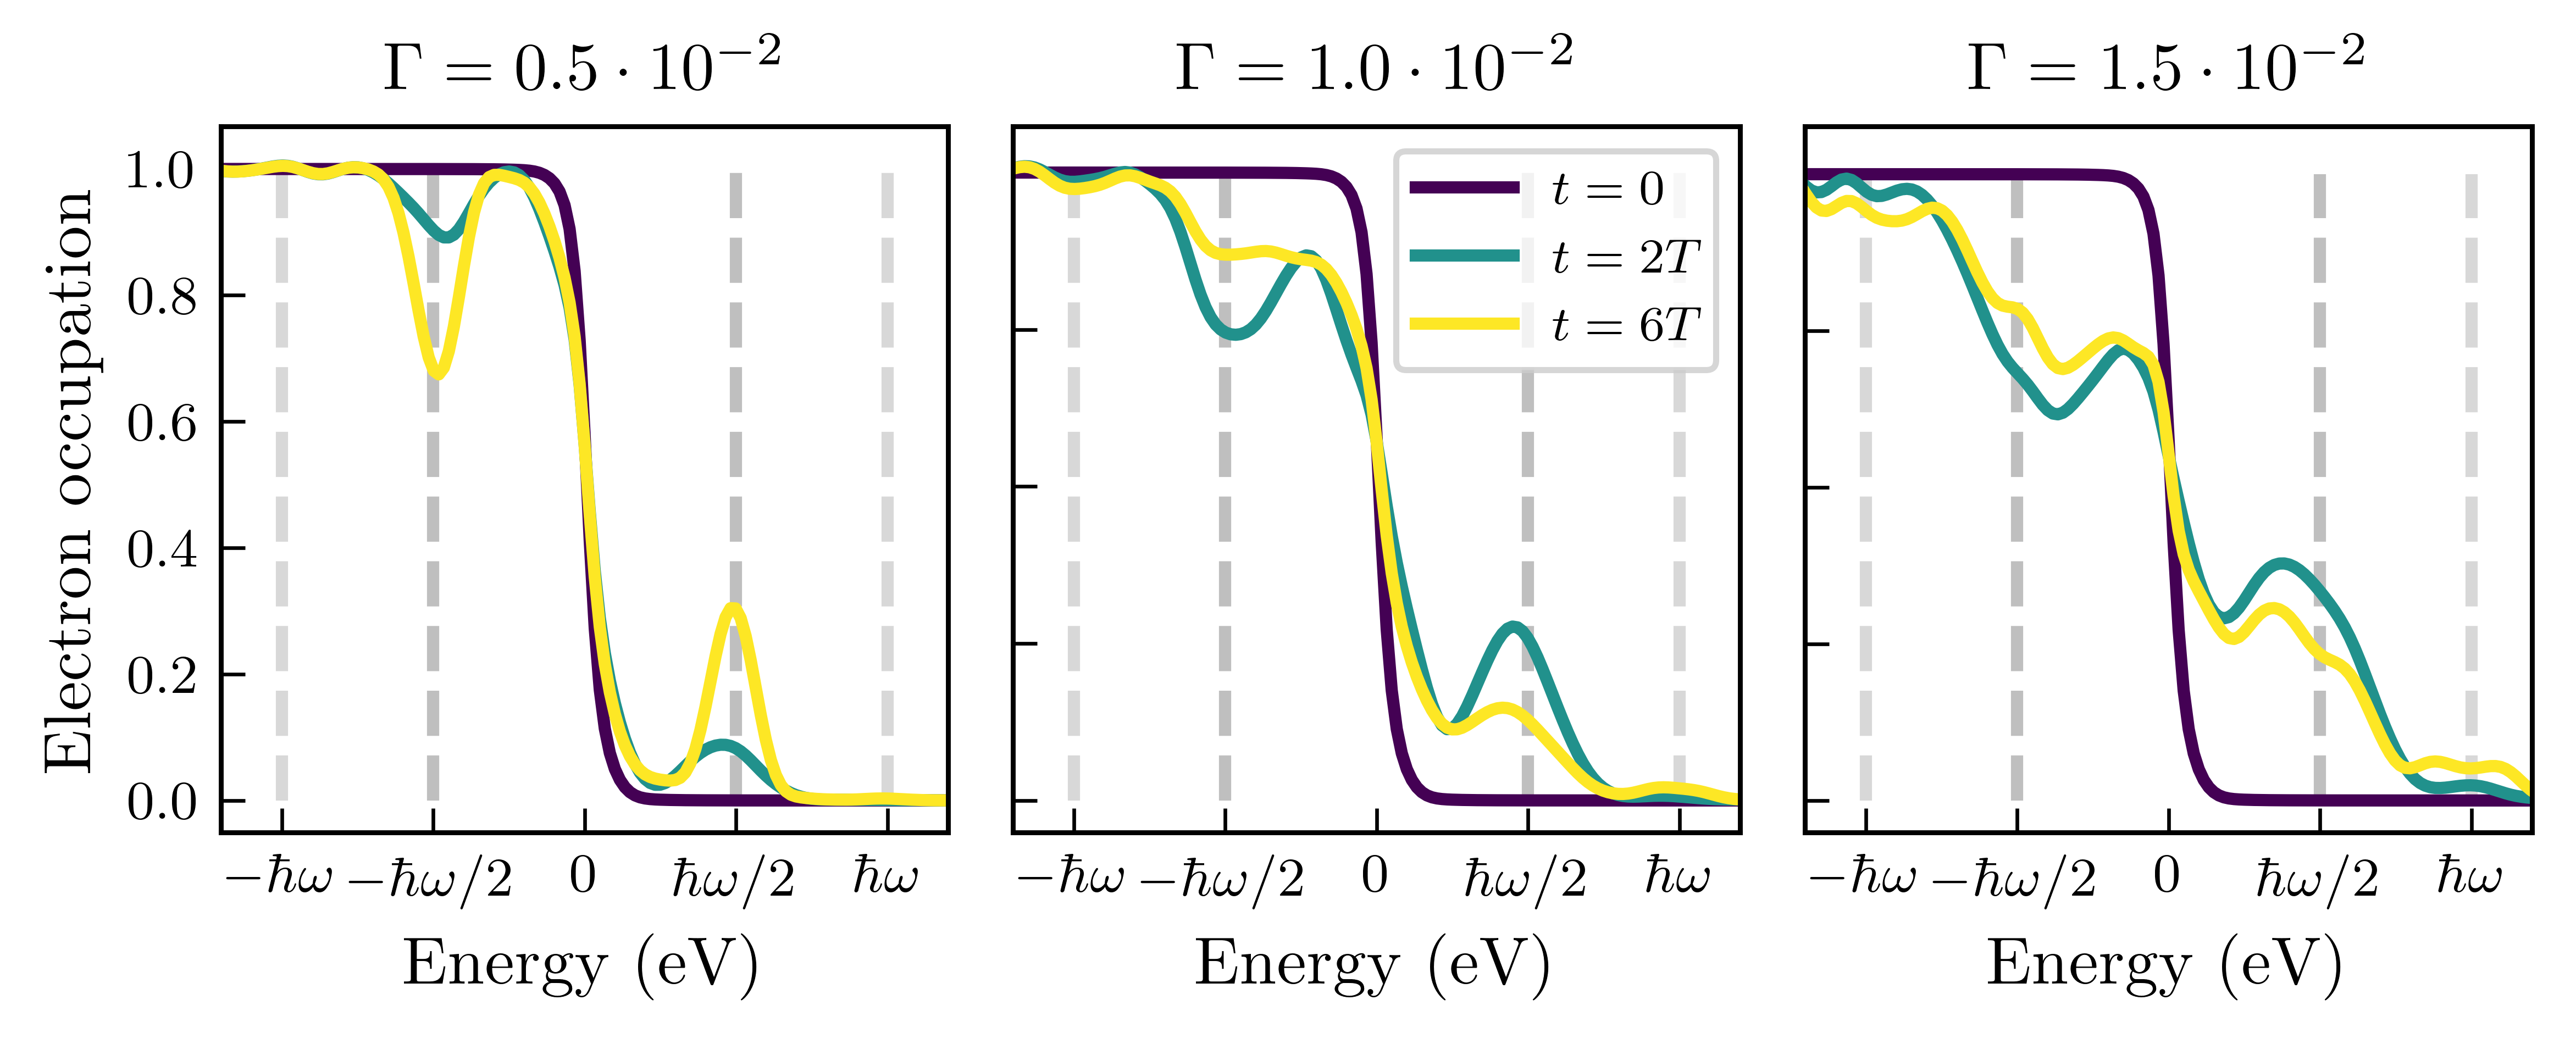

In [60]:
# ----------------------------------------
# OCCUPATION IN ENERGY AT DIFFERENT TIMES
cmap = plt.cm.viridis 
norm = Normalize(vmin=0, vmax=2)
min_e, max_e = -1.2*E, 1.2*E
hw_lines_step = 0.5*E
hw_hlines = [i for i in [hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
hw_hlines += [i for i in [-hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]

color_list = [cmap(norm(0)), cmap(norm(1)), cmap(norm(2))]

# Text box
timeframe_list = [0, 2, 8]
labels_list = ['$t = 0$', '$t = 2T$', '$t = 6T$', '$t = 10T$']


fx_start = 0.09
fx_end = 0.98
fy_start = 0.20
fy_end = 0.88
fx_graph = 0.28
fx_sep = ((fx_end - fx_start) - 3*fx_graph)/2

fig = plt.figure(dpi=800, figsize=(15/2.54, 6/2.54))
ax1 = fig.add_axes((fx_start, fy_start, fx_graph, fy_end - fy_start))
ax2 = fig.add_axes((fx_start + fx_graph + fx_sep, fy_start, fx_graph, fy_end - fy_start))
ax3 = fig.add_axes((fx_start + 2*fx_graph + 2*fx_sep, fy_start, fx_graph, fy_end - fy_start))

ax = [ax1, ax2, ax3]
for (i, res) in enumerate(list_res[1:]):

    sp_time_list = [res['meas_per_T']*tf for tf in timeframe_list]
    ax[i].plot(res0['EF_list'][0,:], res0['n_E_list'][0,:], color=color_list[0], label=labels_list[0])
    for j in range(1, len(timeframe_list)):
        ax[i].plot(res['EF_list'][sp_time_list[j],:], res['n_E_list'][sp_time_list[j],:], color=color_list[j], label=labels_list[j])
    ax[i].set_xlim(min_e, max_e)
    ax[i].vlines([-E, E], 0, 1, color='grey', ls='--', alpha=0.3, zorder=1)
    ax[i].vlines([ -E/2, E/2], 0, 1, color='grey', ls='--', alpha=0.5, zorder=1)
    ax[i].set_xticks([-E, -E/2, 0, E/2, E], labels=['$-\\hbar \\omega$', '$-\\hbar \\omega/2$', '$0$', '$\\hbar \\omega/2$', '$\\hbar \\omega$'])
    ax[i].set_xlabel('Energy (eV)')

ax[0].set_ylabel('Electron occupation')

ax[1].set_yticks([0.0, 0.25, 0.5, 0.75, 1.00], labels=5*[''])
ax[2].set_yticks([0.0, 0.25, 0.5, 0.75, 1.00], labels=5*[''])

ax[0].set_title('$\\Gamma=0.5\\cdot10^{-2}$')
ax[1].set_title('$\\Gamma=1.0\\cdot10^{-2}$')
ax[2].set_title('$\\Gamma=1.5\\cdot10^{-2}$')


ax[1].legend()
fig.savefig('Graphs/neq_multtime.pdf')



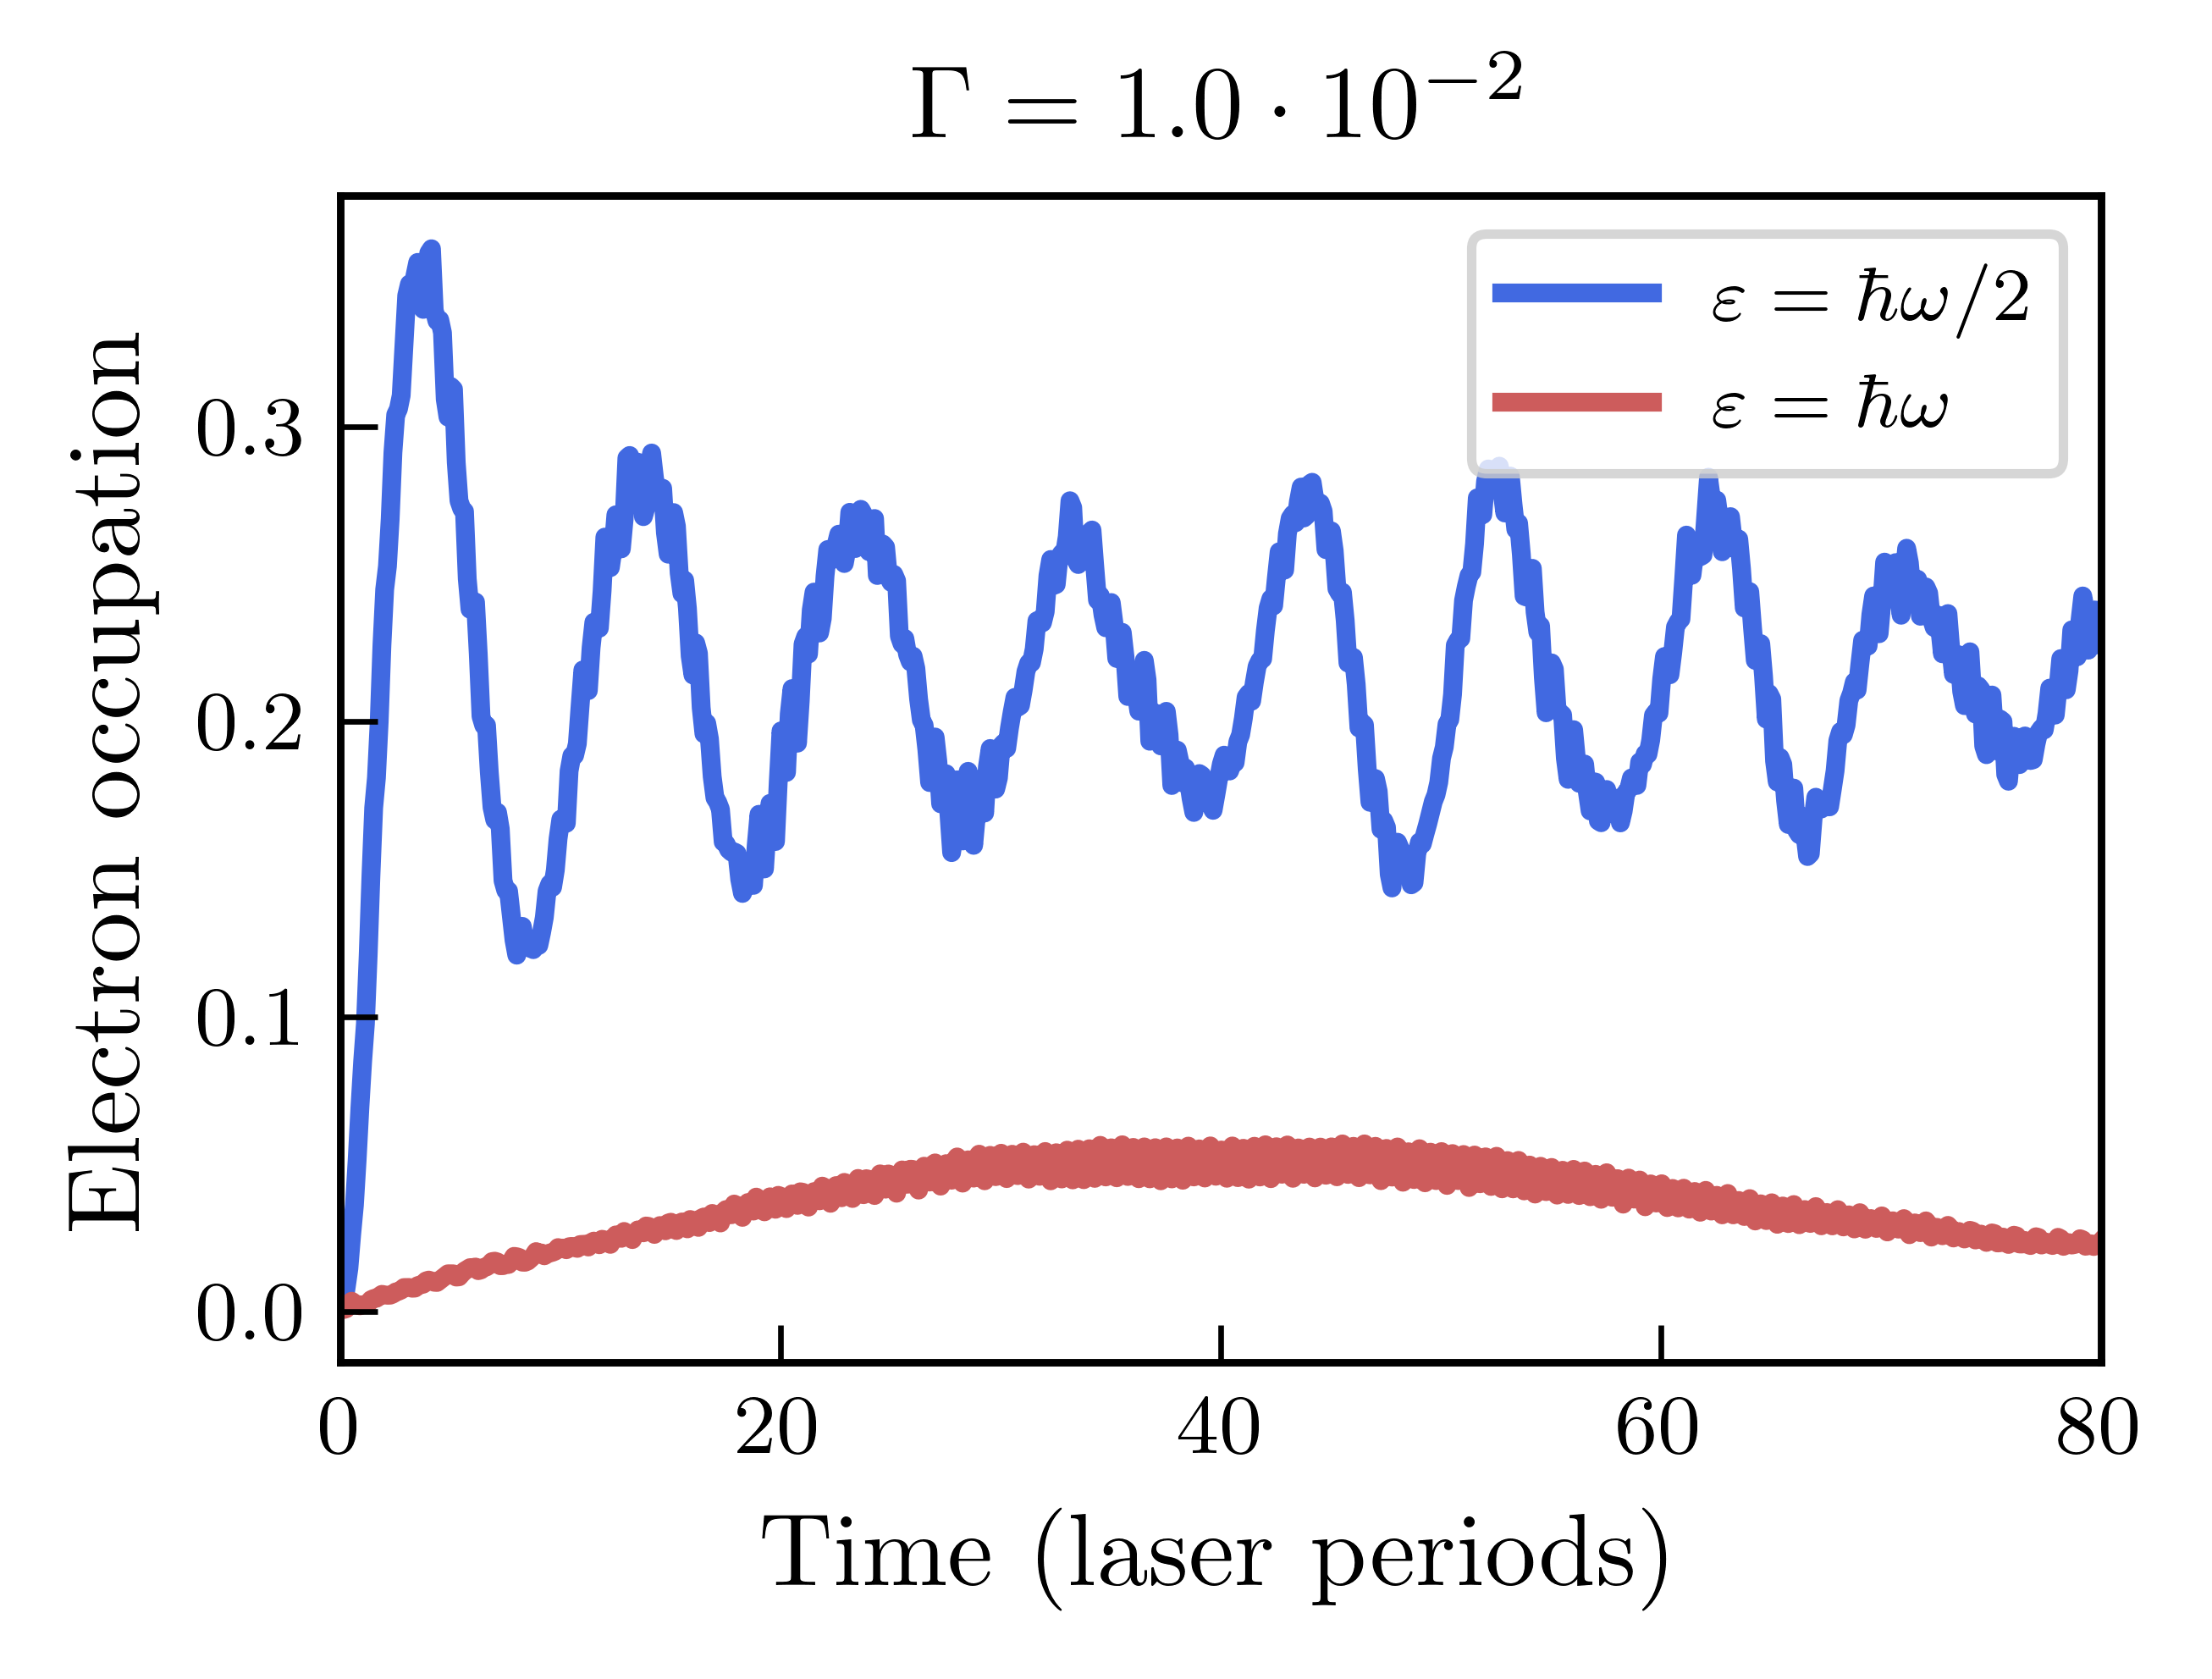

In [61]:
color_s1 = 'royalblue'
color_s2 = 'indianred'
E = 0.5


fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
ax.plot(np.array(res2['t_vec_measures'])/res2['T'], res2['occ_drop_list'][3], c=color_s1, ls='-', label=f"$\\varepsilon=\\hbar\\omega/2$", zorder=1)
ax.plot(np.array(res2['t_vec_measures'])/res2['T'], res2['occ_drop_list'][4], c=color_s2, ls='-', label=f"$\\varepsilon=\\hbar\\omega$", zorder=1)

#ax.set_ylim(-0.02, res['occ_drop_list'][3].max()+0.02)
ax.set_xlabel('Time (laser periods)')

ax.set_title('$\\Gamma=1.0\\cdot10^{-2}$')

ax.set_ylabel('Electron occupation')

ax.set_xlim(0, 80)

ax.legend()
fig.savefig('Graphs/neq_time_p.png')

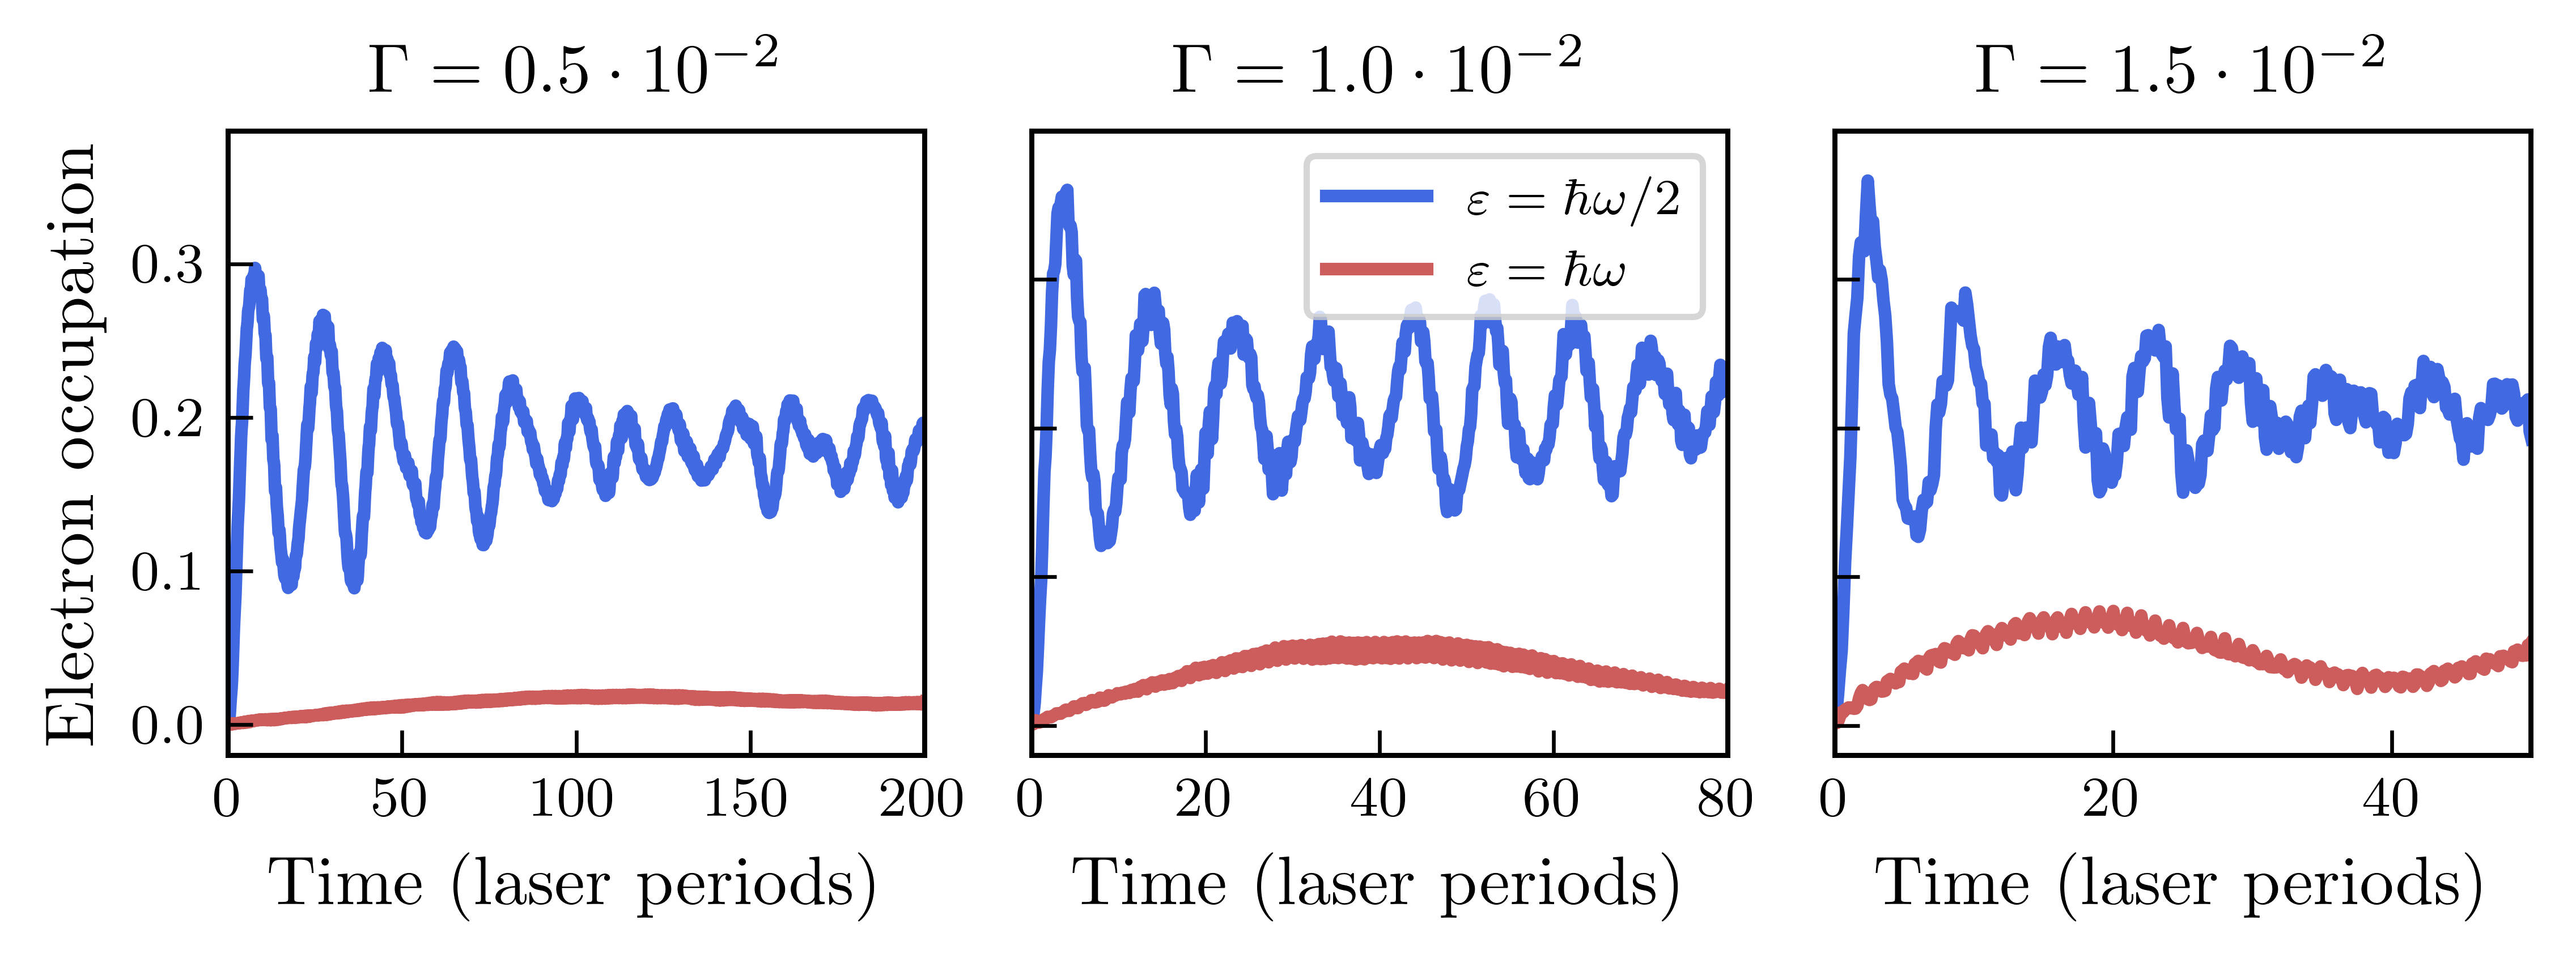

In [62]:
# ------------------------------------------------------------------------------
# OCCUPATION (Time) GRAPH


fx_start = 0.1
fx_end = 0.96
fy_start = 0.18
fy_end = 0.88
fx_graph = 0.26
fx_sep = ((fx_end - fx_start) - 3*fx_graph)/2

fig = plt.figure(dpi=800, figsize=(15/2.54, 5/2.54))
ax1 = fig.add_axes((fx_start, fy_start, fx_graph, fy_end - fy_start))
ax2 = fig.add_axes((fx_start + fx_graph + fx_sep, fy_start, fx_graph, fy_end - fy_start))
ax3 = fig.add_axes((fx_start + 2*fx_graph + 2*fx_sep, fy_start, fx_graph, fy_end - fy_start))

ax = [ax1, ax2, ax3]
max_occ = 0
for (i, res) in enumerate(list_res[1:]):
    #reescale = np.max(res['occ_drop_list'][3]) / np.max(res['occ_drop_list'][4]) / 2
    ax[i].plot(np.array(res['t_vec_measures'])/res['T'], res['occ_drop_list'][3], c=color_s1, ls='-', label=f"$\\varepsilon=\\hbar\\omega/2$", zorder=1)
    ax[i].plot(np.array(res['t_vec_measures'])/res['T'], res['occ_drop_list'][4], c=color_s2, ls='-', label=f"$\\varepsilon=\\hbar\\omega$", zorder=1)
    #ax[i].plot(np.array(res['t_vec_measures'])/res['T'], res['occ_drop_list'][4]*reescale, c=color_s2, ls='-', label=f"$\\varepsilon=\\hbar\\omega$")
    
    if max(res['occ_drop_list'][3]) > max_occ:
        max_occ = max(res['occ_drop_list'][3])
    
for i in range(3):
    ax[i].set_ylim(-0.02, max_occ+0.02)
    ax[i].set_xlabel('Time (laser periods)')


ax[1].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4], labels=5*[''])
ax[2].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4], labels=5*[''])

ax[0].set_title('$\\Gamma=0.5\\cdot10^{-2}$')
ax[1].set_title('$\\Gamma=1.0\\cdot10^{-2}$')
ax[2].set_title('$\\Gamma=1.5\\cdot10^{-2}$')

ax[0].set_ylabel('Electron occupation')

ax[0].set_xlim(0, 200)
ax[1].set_xlim(0, 80)
ax[2].set_xlim(0, 50)

ax[1].legend()
fig.savefig('Graphs/neq_time.pdf')
#ax.set_xlabel('Time (Periods)')
#ax.set_ylabel('Electron Occupation')
#ax.set_xlim(0, 100)
#ax.set_title(fr'Occupation')
#fig.suptitle(fig_title_info)
#fig.savefig('Graphs/neq_n(t).pdf')
#ax.legend()


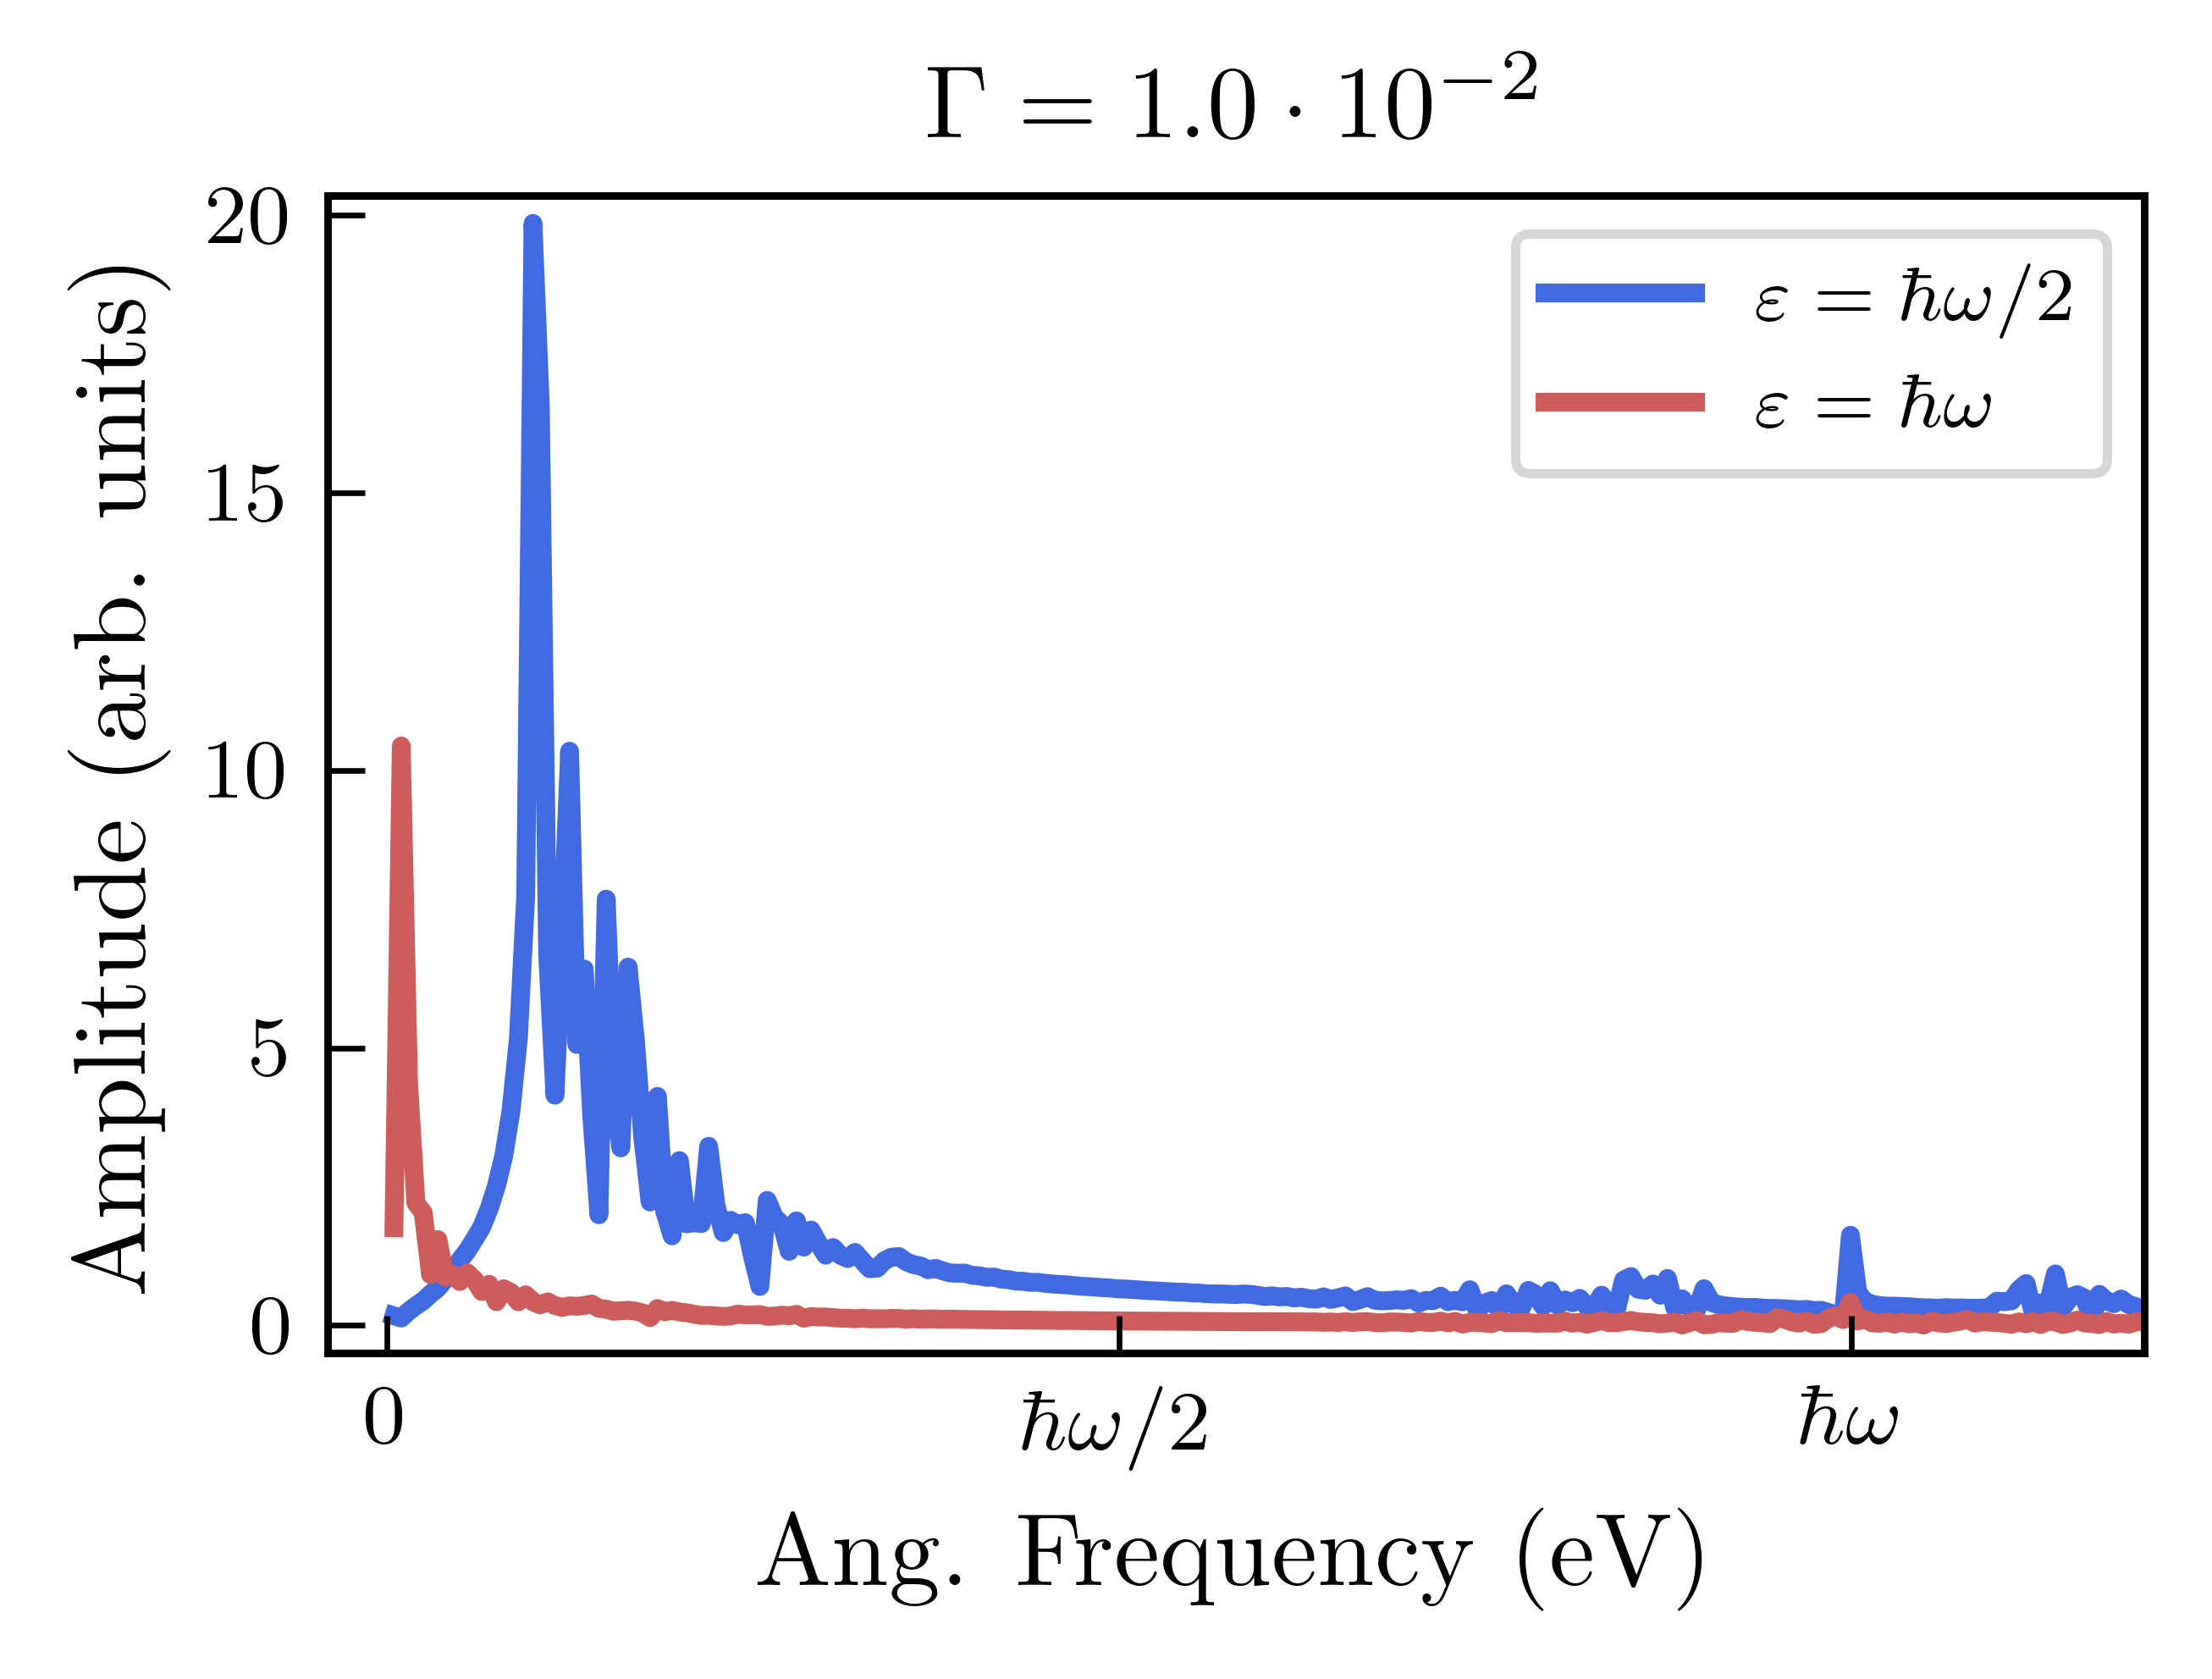

In [63]:

fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
ax.plot(res2['freq']*hbar, res2['fourier_occ'][3], c=color_s1, ls='-', label=f"$\\varepsilon=\\hbar\\omega/2$", zorder=1)
ax.plot(res2['freq']*hbar, res2['fourier_occ'][4], c=color_s2, ls='-', label=f"$\\varepsilon=\\hbar\\omega$", zorder=1)

#ax.set_ylim(-0.02, res['occ_drop_list'][3].max()+0.02)
ax.set_xlabel('Ang. Frequency (eV)')
ax.set_xlim(-0.02, 0.6)
ax.set_ylim(-0.5, res2['fourier_occ'][3].max()+0.5)
ax.set_xticks([0, 0.25, 0.5], labels=['$0$', '$\\hbar \\omega/2$', '$\\hbar \\omega$'])


ax.set_title('$\\Gamma=1.0\\cdot10^{-2}$')
ax.set_ylabel('Amplitude (arb. units)')

ax.legend()
fig.savefig('Graphs/neq_fourier_p.png')

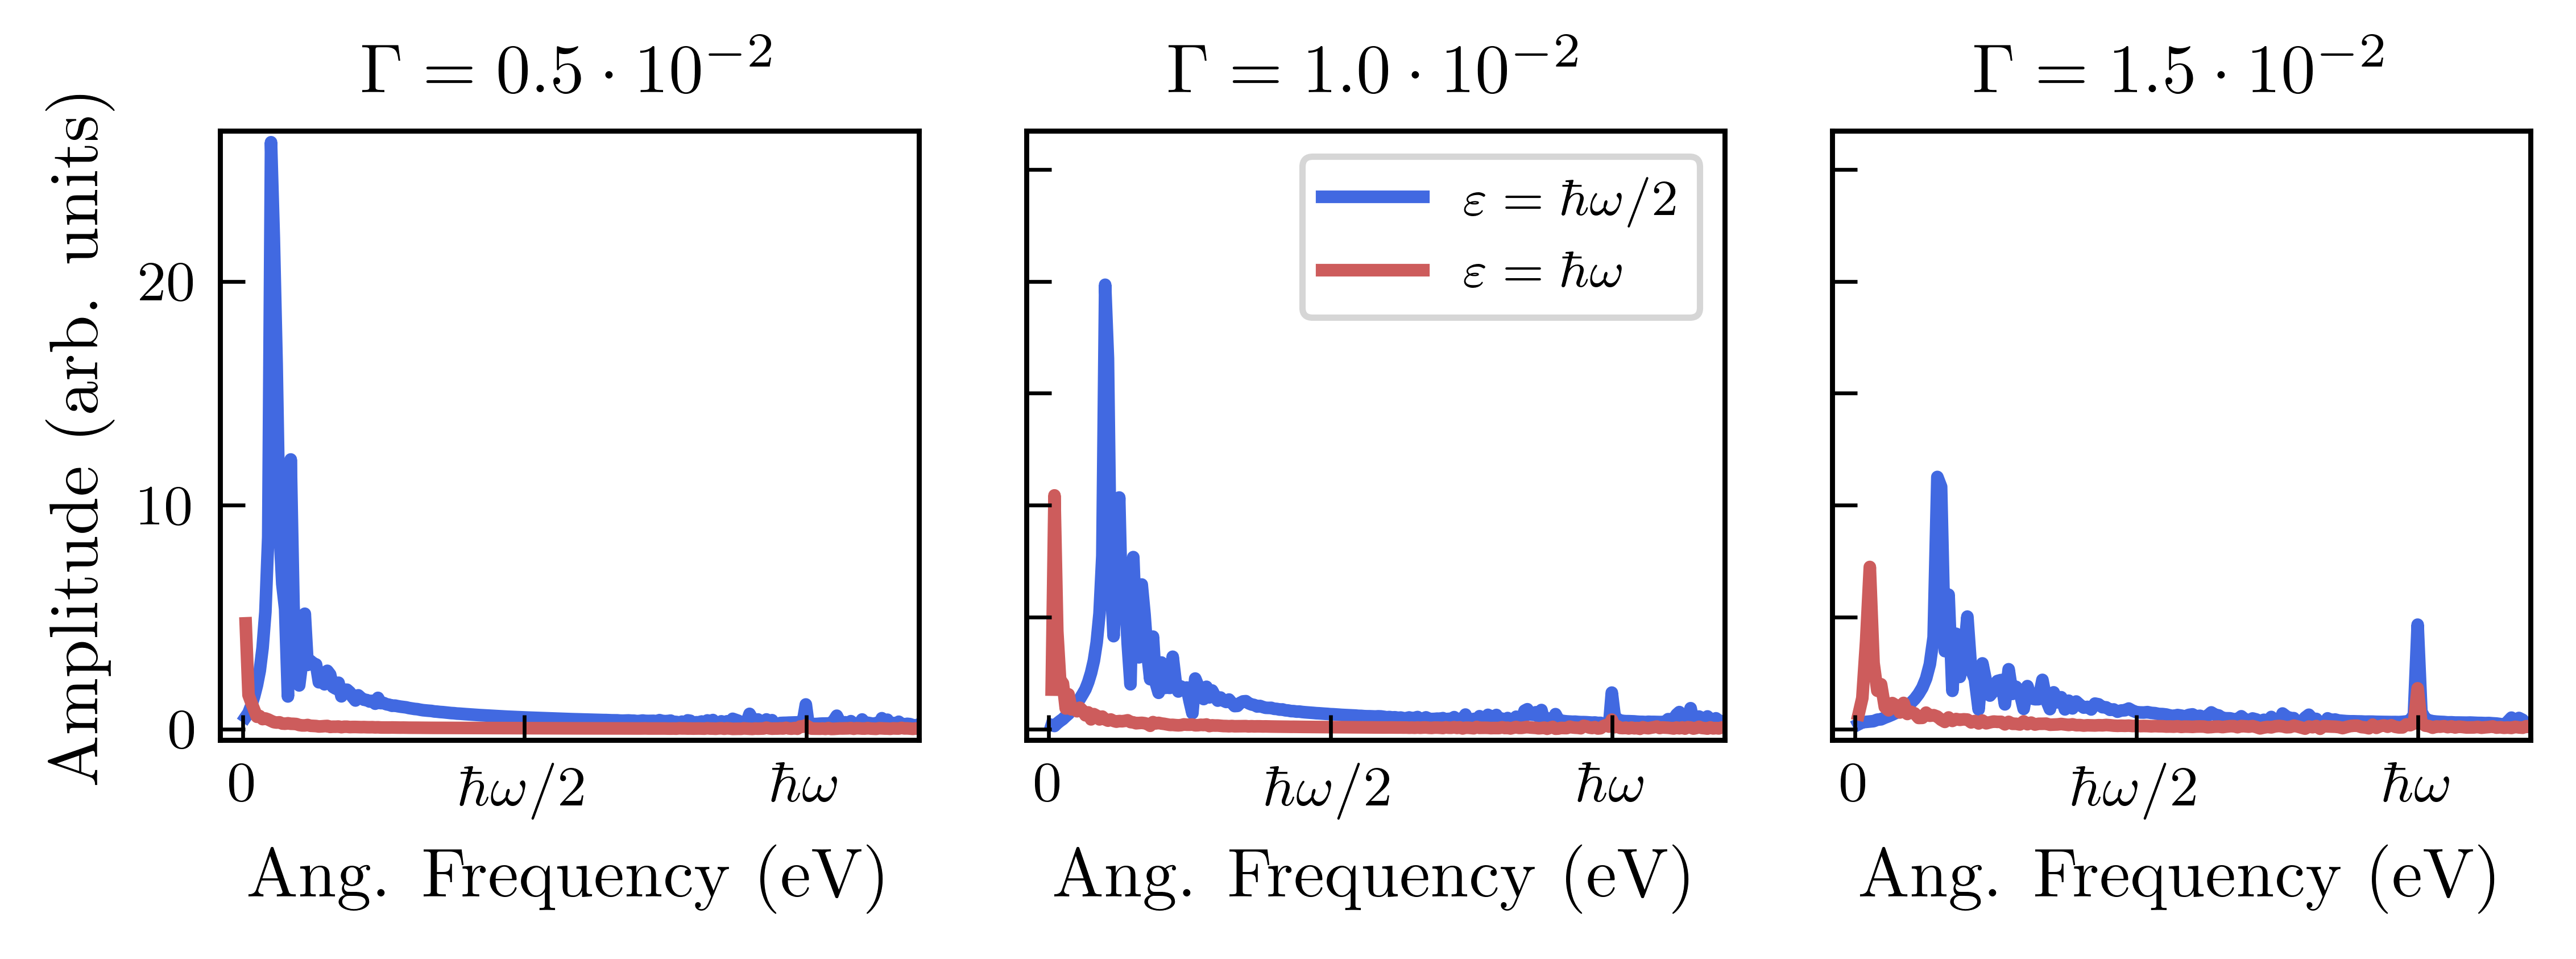

In [64]:
# ------------------------------------------------------------------------------
# OCCUPATION (Time) GRAPH
fx_start = 0.1
fx_end = 0.96
fy_start = 0.2
fy_end = 0.88
fx_graph = 0.26
fx_sep = ((fx_end - fx_start) - 3*fx_graph)/2

fig = plt.figure(dpi=800, figsize=(15/2.54, 5/2.54))
ax1 = fig.add_axes((fx_start, fy_start, fx_graph, fy_end - fy_start))
ax2 = fig.add_axes((fx_start + fx_graph + fx_sep, fy_start, fx_graph, fy_end - fy_start))
ax3 = fig.add_axes((fx_start + 2*fx_graph + 2*fx_sep, fy_start, fx_graph, fy_end - fy_start))

ax = [ax1, ax2, ax3]
max_occ = 0
for (i, res) in enumerate(list_res[1:]):
    #reescale = np.max(res['occ_drop_list'][3]) / np.max(res['occ_drop_list'][4]) / 2
    ax[i].plot(res['freq']*hbar, res['fourier_occ'][3], c=color_s1, ls='-', label=f"$\\varepsilon=\\hbar\\omega/2$", zorder=1)
    ax[i].plot(res['freq']*hbar, res['fourier_occ'][4], c=color_s2, ls='-', label=f"$\\varepsilon=\\hbar\\omega$", zorder=1)
    #ax[i].plot(np.array(res['t_vec_measures'])/res['T'], res['occ_drop_list'][4]*reescale, c=color_s2, ls='-', label=f"$\\varepsilon=\\hbar\\omega$")
    
    if max(res['occ_drop_list'][3]) > max_occ:
        max_occ = max(res['fourier_occ'][3])
    
for i in range(3):
    #ax[i].set_ylim(-0.02, max_occ+0.02)
    ax[i].set_xlabel('Ang. Frequency (eV)')
    ax[i].set_xlim(-0.02, 0.6)
    ax[i].set_ylim(-0.5, max_occ+0.5)
    #ax[i].set_xticks([0, 0.25, 0.5], labels=['$0$', '$\\frac{\\hbar \\omega}{2}$', '$\\hbar \\omega$'])
    ax[i].set_xticks([0, 0.25, 0.5], labels=['$0$', '$\\hbar \\omega/2$', '$\\hbar \\omega$'])

ax[0].set_title('$\\Gamma=0.5\\cdot10^{-2}$')
ax[1].set_title('$\\Gamma=1.0\\cdot10^{-2}$')
ax[2].set_title('$\\Gamma=1.5\\cdot10^{-2}$')

ax[1].set_yticks([0, 5, 10, 15, 20, 25], labels=6*[''])
ax[2].set_yticks([0, 5, 10, 15, 20, 25], labels=6*[''])

ax[0].set_ylabel('Amplitude (arb. units)')
ax[1].legend()
fig.savefig('Graphs/neq_fourier.pdf')

In [65]:
# CHAR FREQ WITH LASER AMPLIUTDE


gamma_list = np.linspace(0.00, 0.025, 6)
timeframe_intensity_list = [(0.000, 100, 4, 0.5),
                            (0.005, 200, 8, 0.5),
                            (0.010, 200, 8, 0.5),
                            (0.015, 150, 8, 0.5),
                            (0.020, 100, 16, 0.5),
                            (0.025, 100, 16, 0.5),
                            (0.030, 80, 24, 0.5),
                            (0.035, 80, 24, 0.5),
                            (0.040, 50, 32, 0.5),
                            (0.045, 50, 32, 0.5),
                            (0.050, 50, 32, 0.5)]
res = copy.deepcopy(res1)
res['char_freq'] = np.zeros((len(gamma_list), 2*hE_reps+1))

res_hbn = copy.deepcopy(res)
res_hbn['type_ham'] = 'hbn'



for (g, gamma) in enumerate(gamma_list):
    if M == 0:
        M = int(np.sqrt(N))
    
    res['gamma'] = gamma
    res['n_periods'], res['meas_per_T'], res['hw'] = timeframe_intensity_list[g][1:]
    res['t_vec'] = np.linspace(0,res['n_periods']*res['T'] , res['steps_per_T']*res['n_periods'])   
    res['t_vec_measures'] = np.linspace(0, res['n_periods']*res['T'], res['meas_per_T']*res['n_periods'])
    load_data_dict(res, out_file_loc=out_loc)
    frequency_analysis_dict(res, use_dosn=True)
    res['char_freq'][g] = res['char_freq_s']
    
    res_hbn['gamma'] = gamma
    res_hbn['n_periods'], res_hbn['meas_per_T'], res_hbn['hw'] = timeframe_intensity_list[g][1:]
    res_hbn['t_vec'] = np.linspace(0,res_hbn['n_periods']*res_hbn['T'] , res_hbn['steps_per_T']*res_hbn['n_periods'])   
    res_hbn['t_vec_measures'] = np.linspace(0, res_hbn['n_periods']*res_hbn['T'], res_hbn['meas_per_T']*res_hbn['n_periods'])
    load_data_dict(res_hbn, out_file_loc=out_loc)
    frequency_analysis_dict(res_hbn)
    res_hbn['char_freq'][g] = res_hbn['char_freq_s']
    


5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...


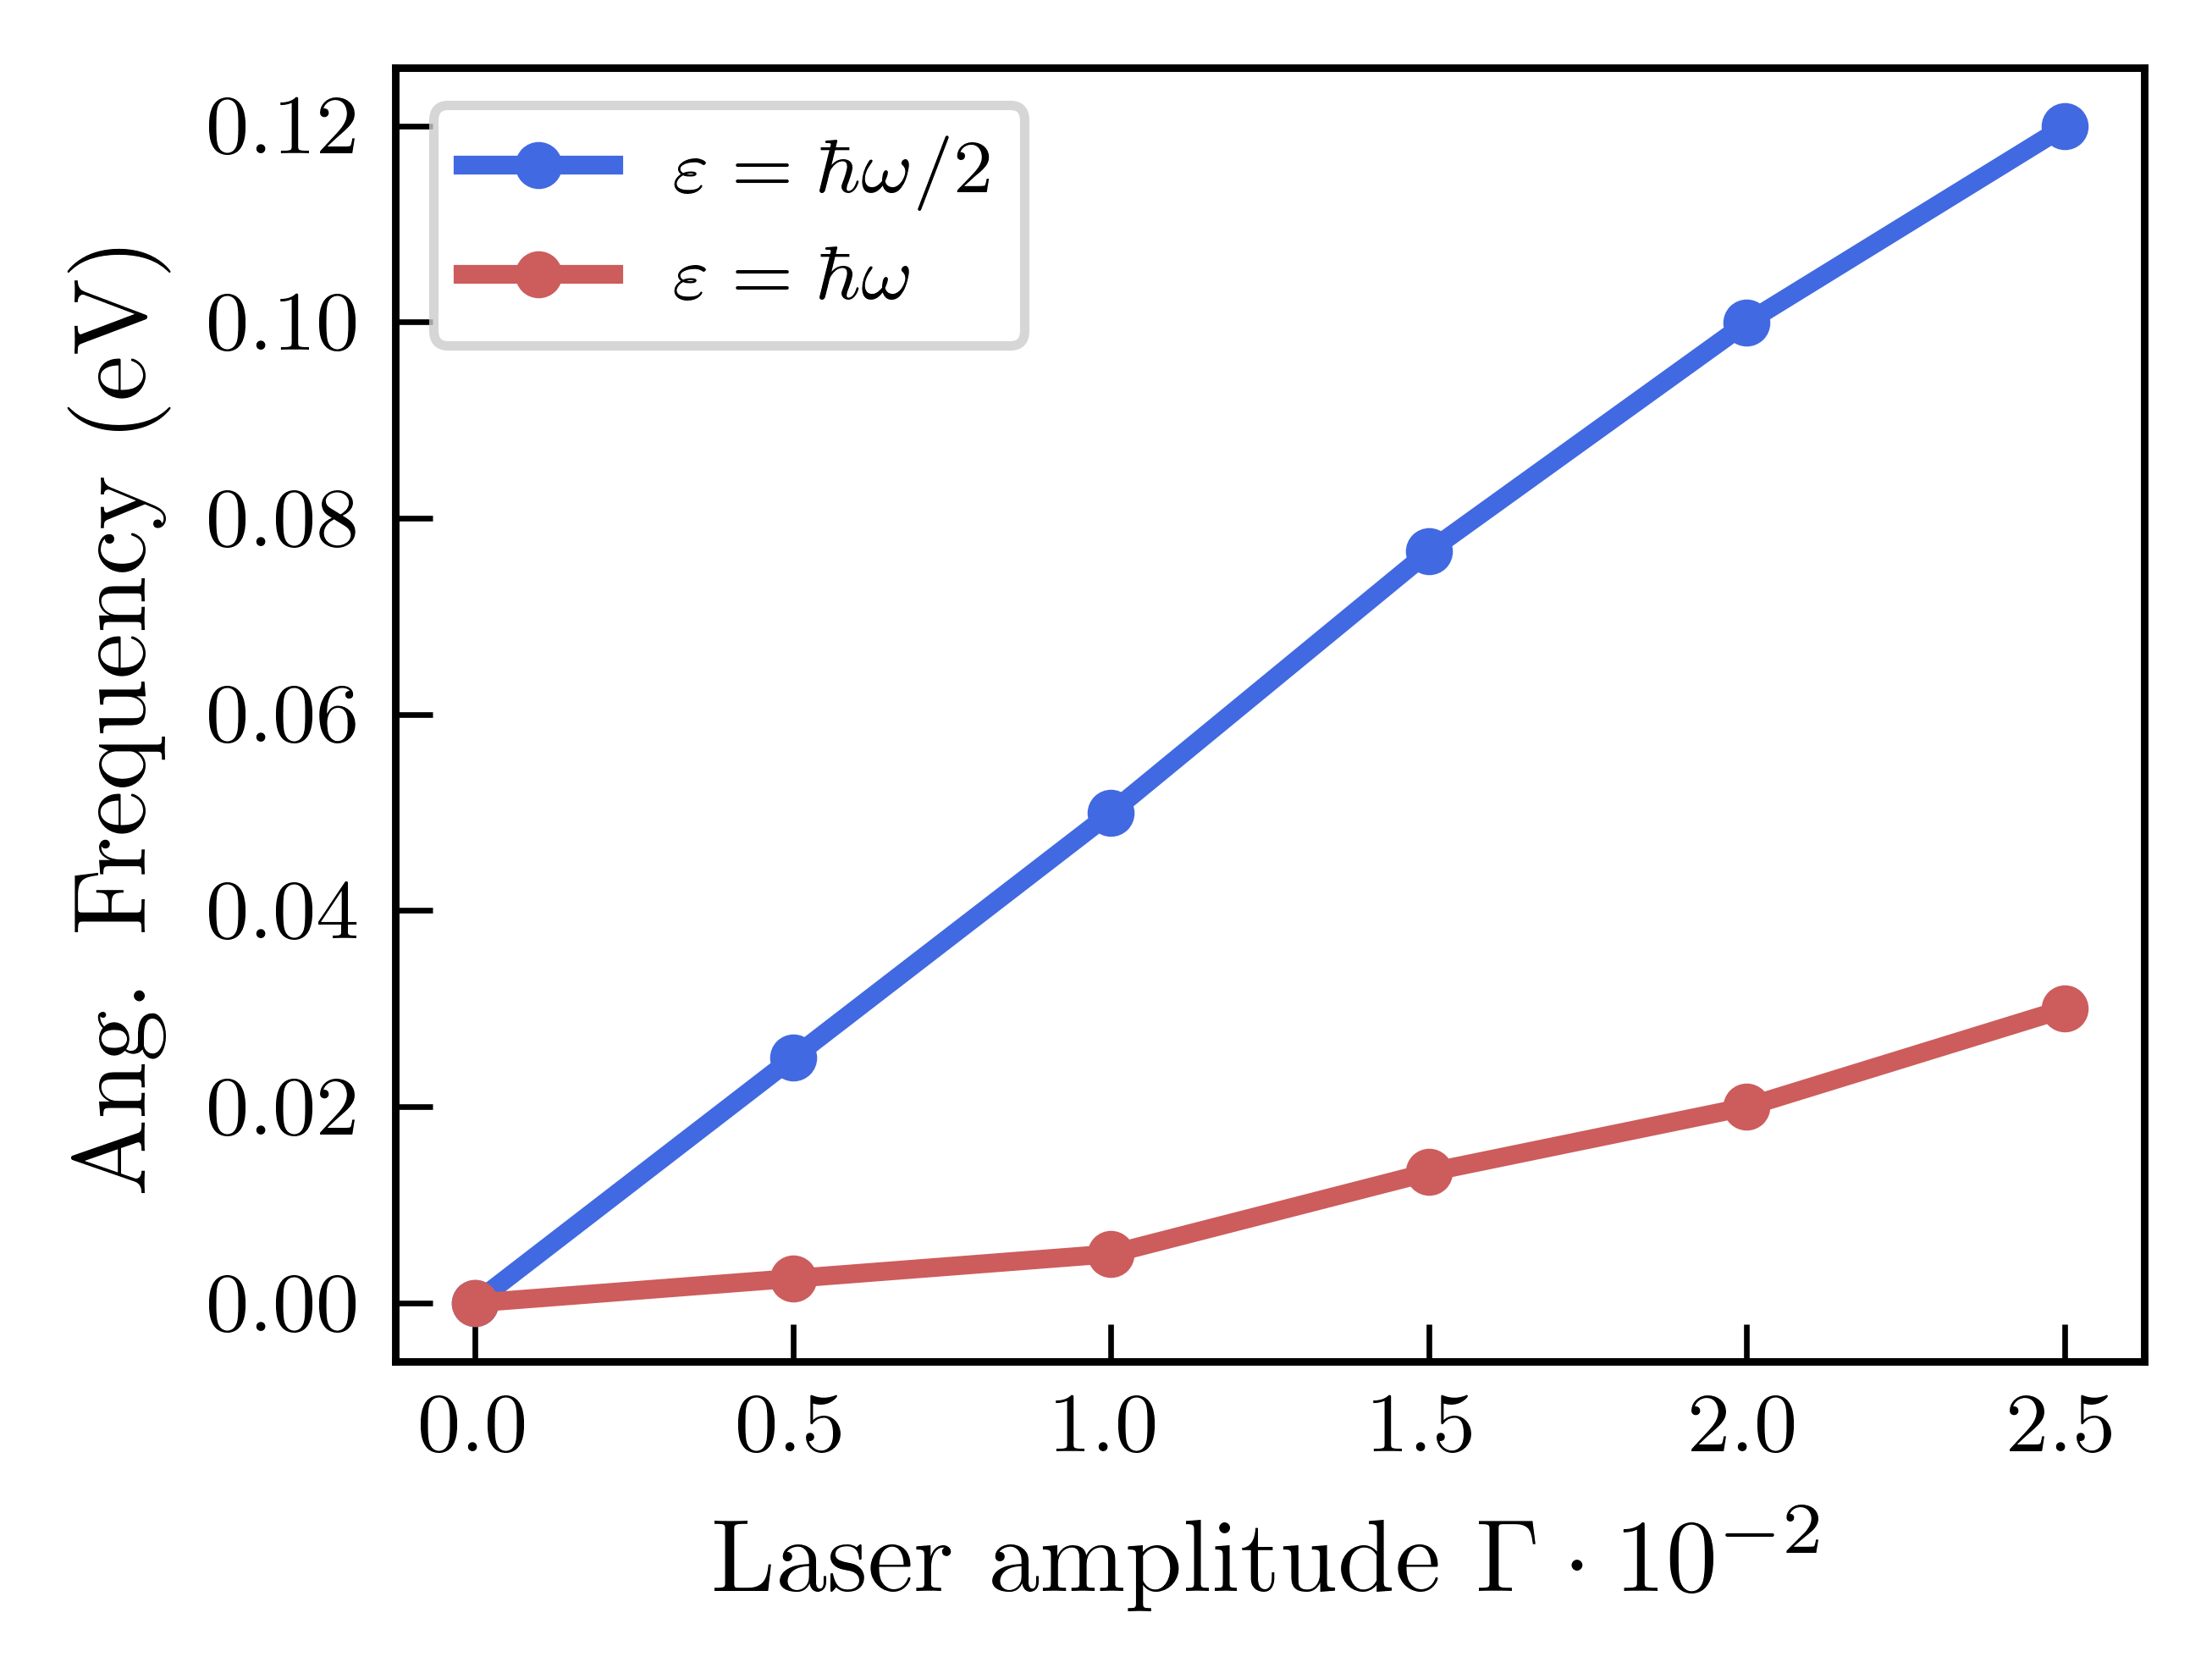

In [66]:
# Final plot of the gammas
fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
#ax.plot(gamma_list, char_freq[:,2], ls='--', c=color_list[2], marker='.',
#        label=f'$E = \\mu$ eV')
ax.plot(gamma_list*100, res['char_freq'][:,3]*hbar, ls='-', c=color_s1, marker='.', markersize=10, label=f'$\\varepsilon = \\hbar\\omega/2$')
ax.plot(gamma_list*100, res['char_freq'][:,4]*hbar, ls='-', c=color_s2, marker='.', markersize=10, label=f'$\\varepsilon =\\hbar\\omega$')
ax.set_xlabel('Laser amplitude $\\Gamma \\cdot 10^{-2}$')
ax.set_ylabel('Ang. Frequency (eV)')
ax.legend()
#ax.set_xticks(gamma_list)
#fig.suptitle(f'$N={{{2**N_pot}}}$, $\\hbar\\omega$={E} eV, Temp={Temp} K, $\\mu$={mu} eV')
fig.savefig('Graphs/neq_freqs.png')

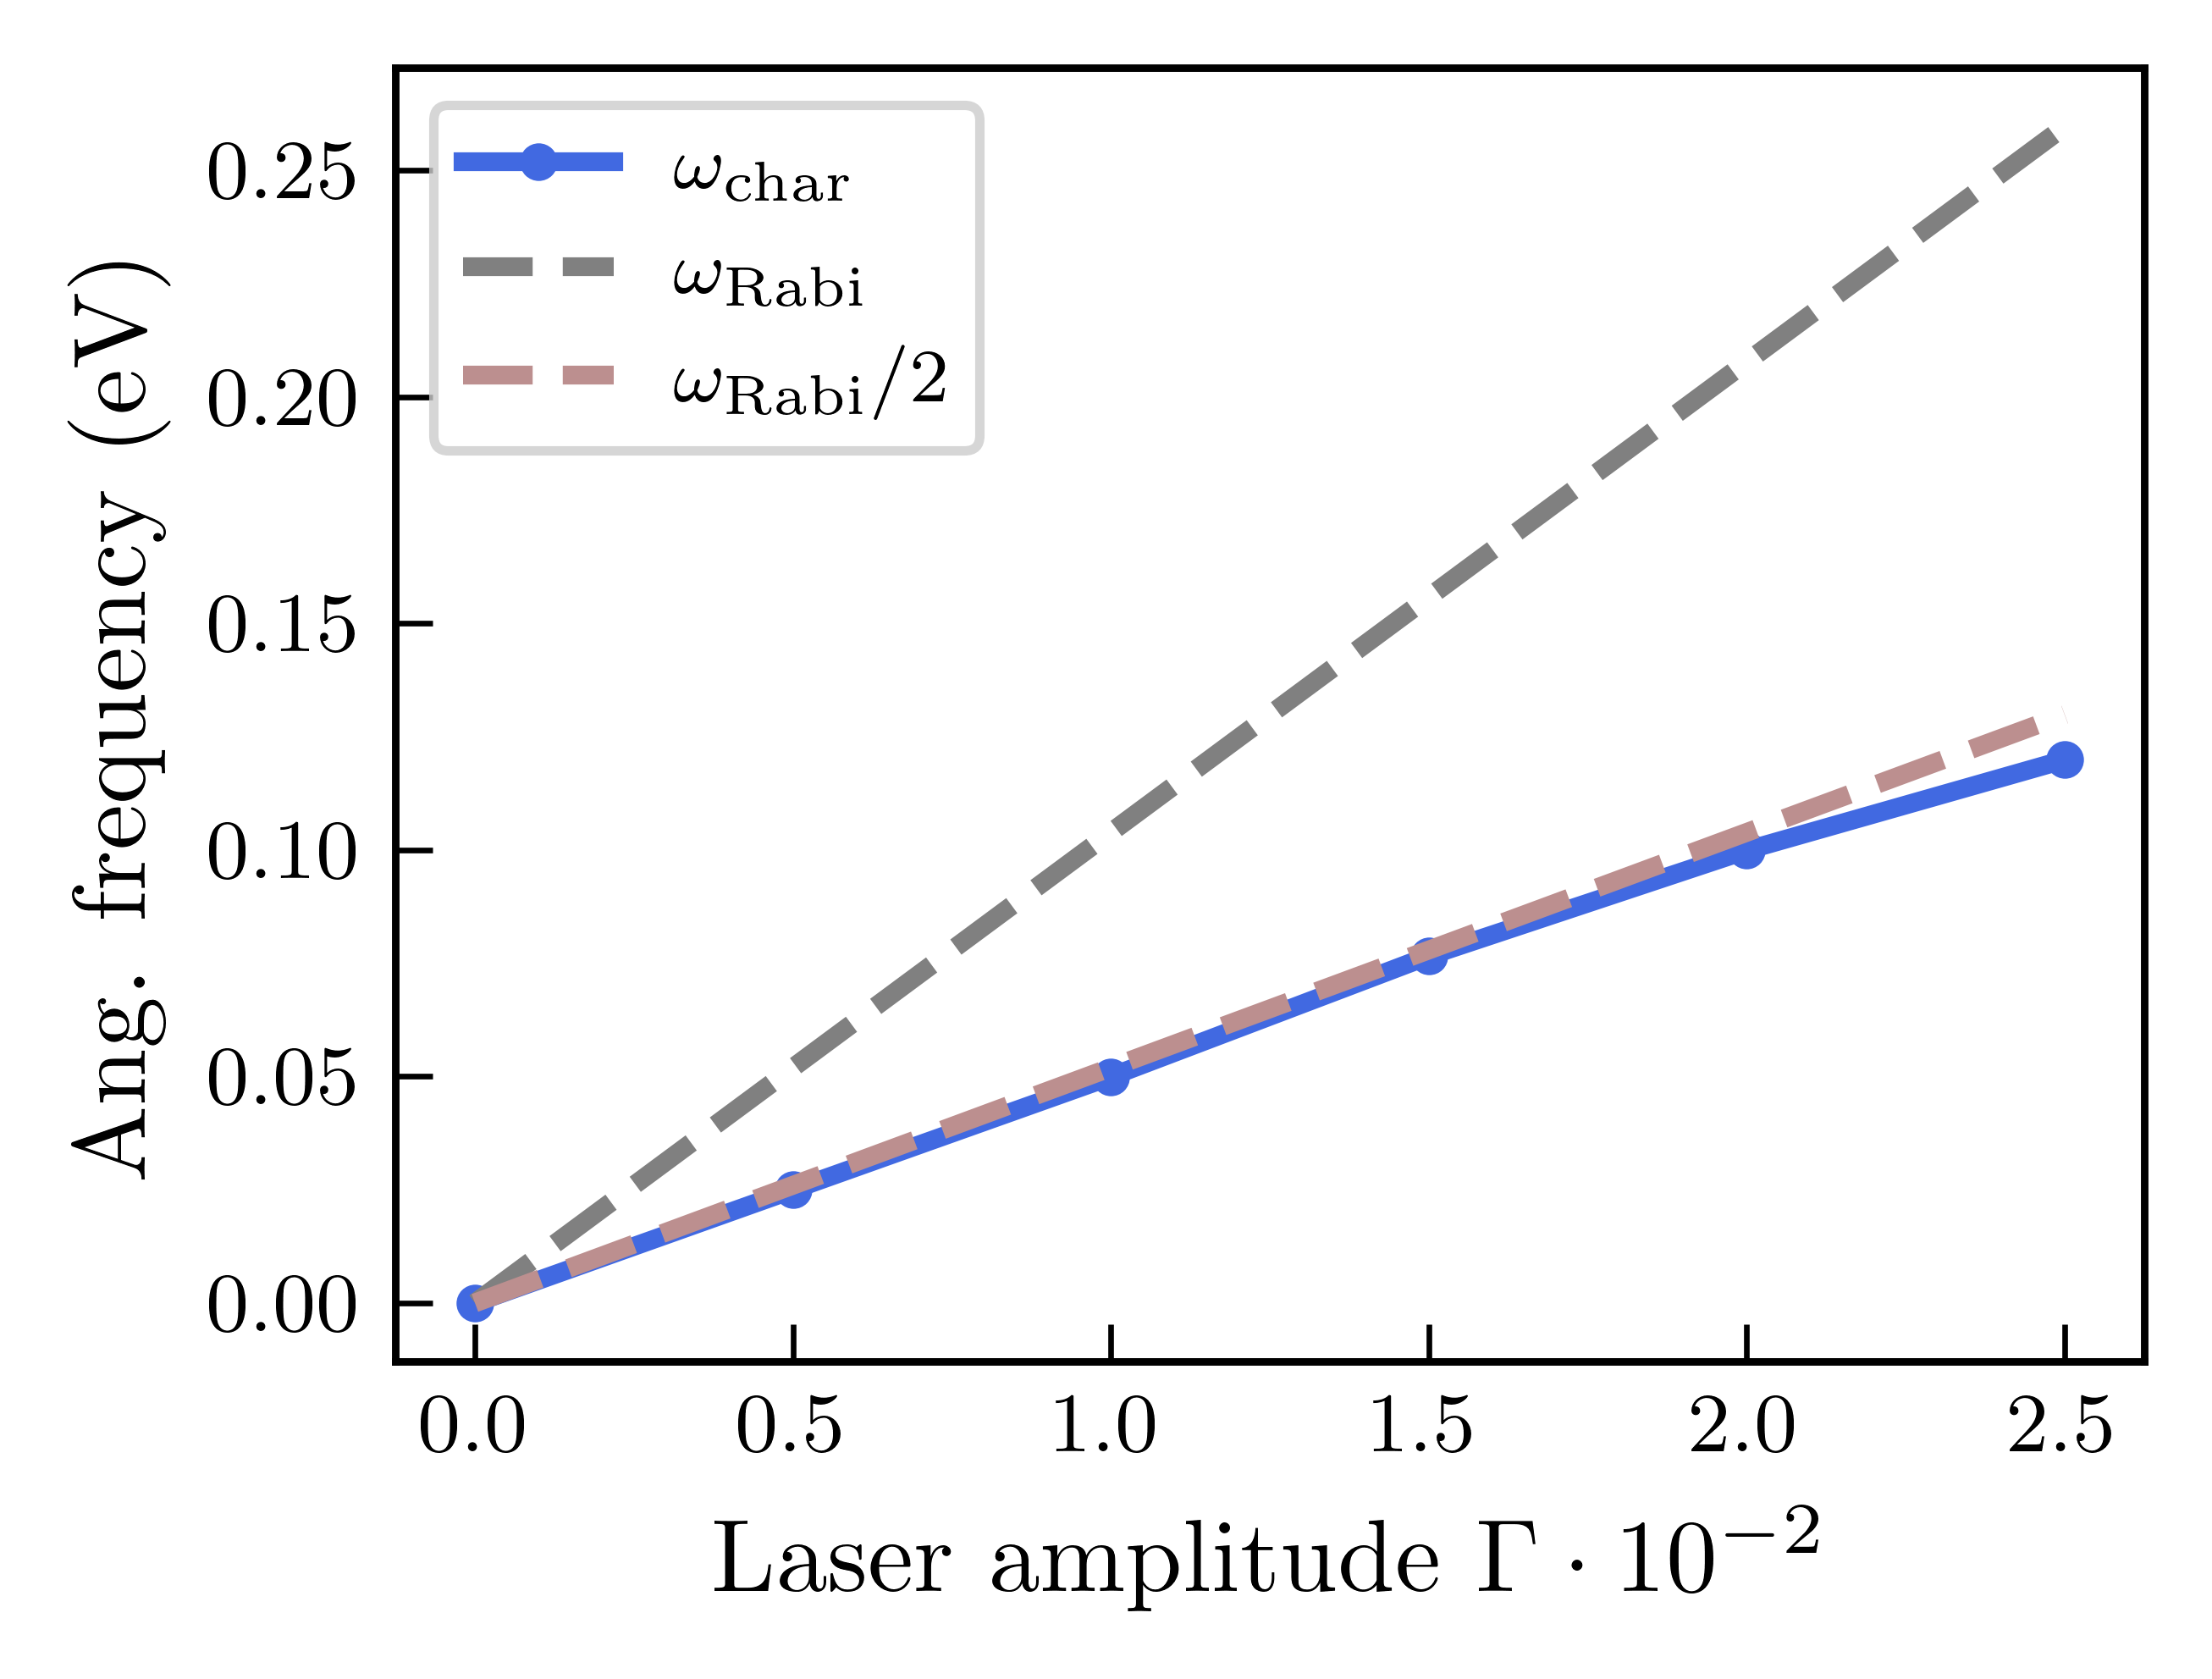

In [67]:
t = -2.7
Phi0 = 2*np.pi*hbar
if modifier_id == 'circln':
    w1 = np.sqrt(3)*t*gamma_list*np.pi/hbar/2**0.5
else:
     w1 = np.sqrt(3)*t*gamma_list*np.pi/hbar
#w1 = 2*vf*A0/hbar


rep = 1
delta_w = (1-rep)*res['w']
#delta_w = w_laser - gap1_fl/jcl.hbar_fs
rabi_freq = np.sqrt(delta_w**2 + w1**2)
#rabi_freq = 2*vf*A0/jcl.hbar_fs*np.sqrt(1+E**2/(vf**2*A0**2))



fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
ax.plot(gamma_list*100, res['char_freq'][:,3]*hbar, ls='-', c=color_s1, marker='.', markersize=8, label='$\\omega_\\mathrm{char}$')
ax.plot(gamma_list*100, rabi_freq*hbar, ls='--', c='grey', label='$\\omega_\\mathrm{Rabi}$')
ax.plot(gamma_list*100, rabi_freq/2*hbar, ls='--', c='rosybrown', label='$\\omega_\\mathrm{Rabi}/2$')
#ax.set_title('Characteristic Frequencies in $E=0.5\\hbar\\omega$')
ax.set_xlabel('Laser amplitude $\\Gamma \\cdot 10^{-2}$')
ax.set_ylabel('Ang. frequency (eV)')
ax.legend()
fig.savefig('Graphs/neq_rabi_comp.pdf')



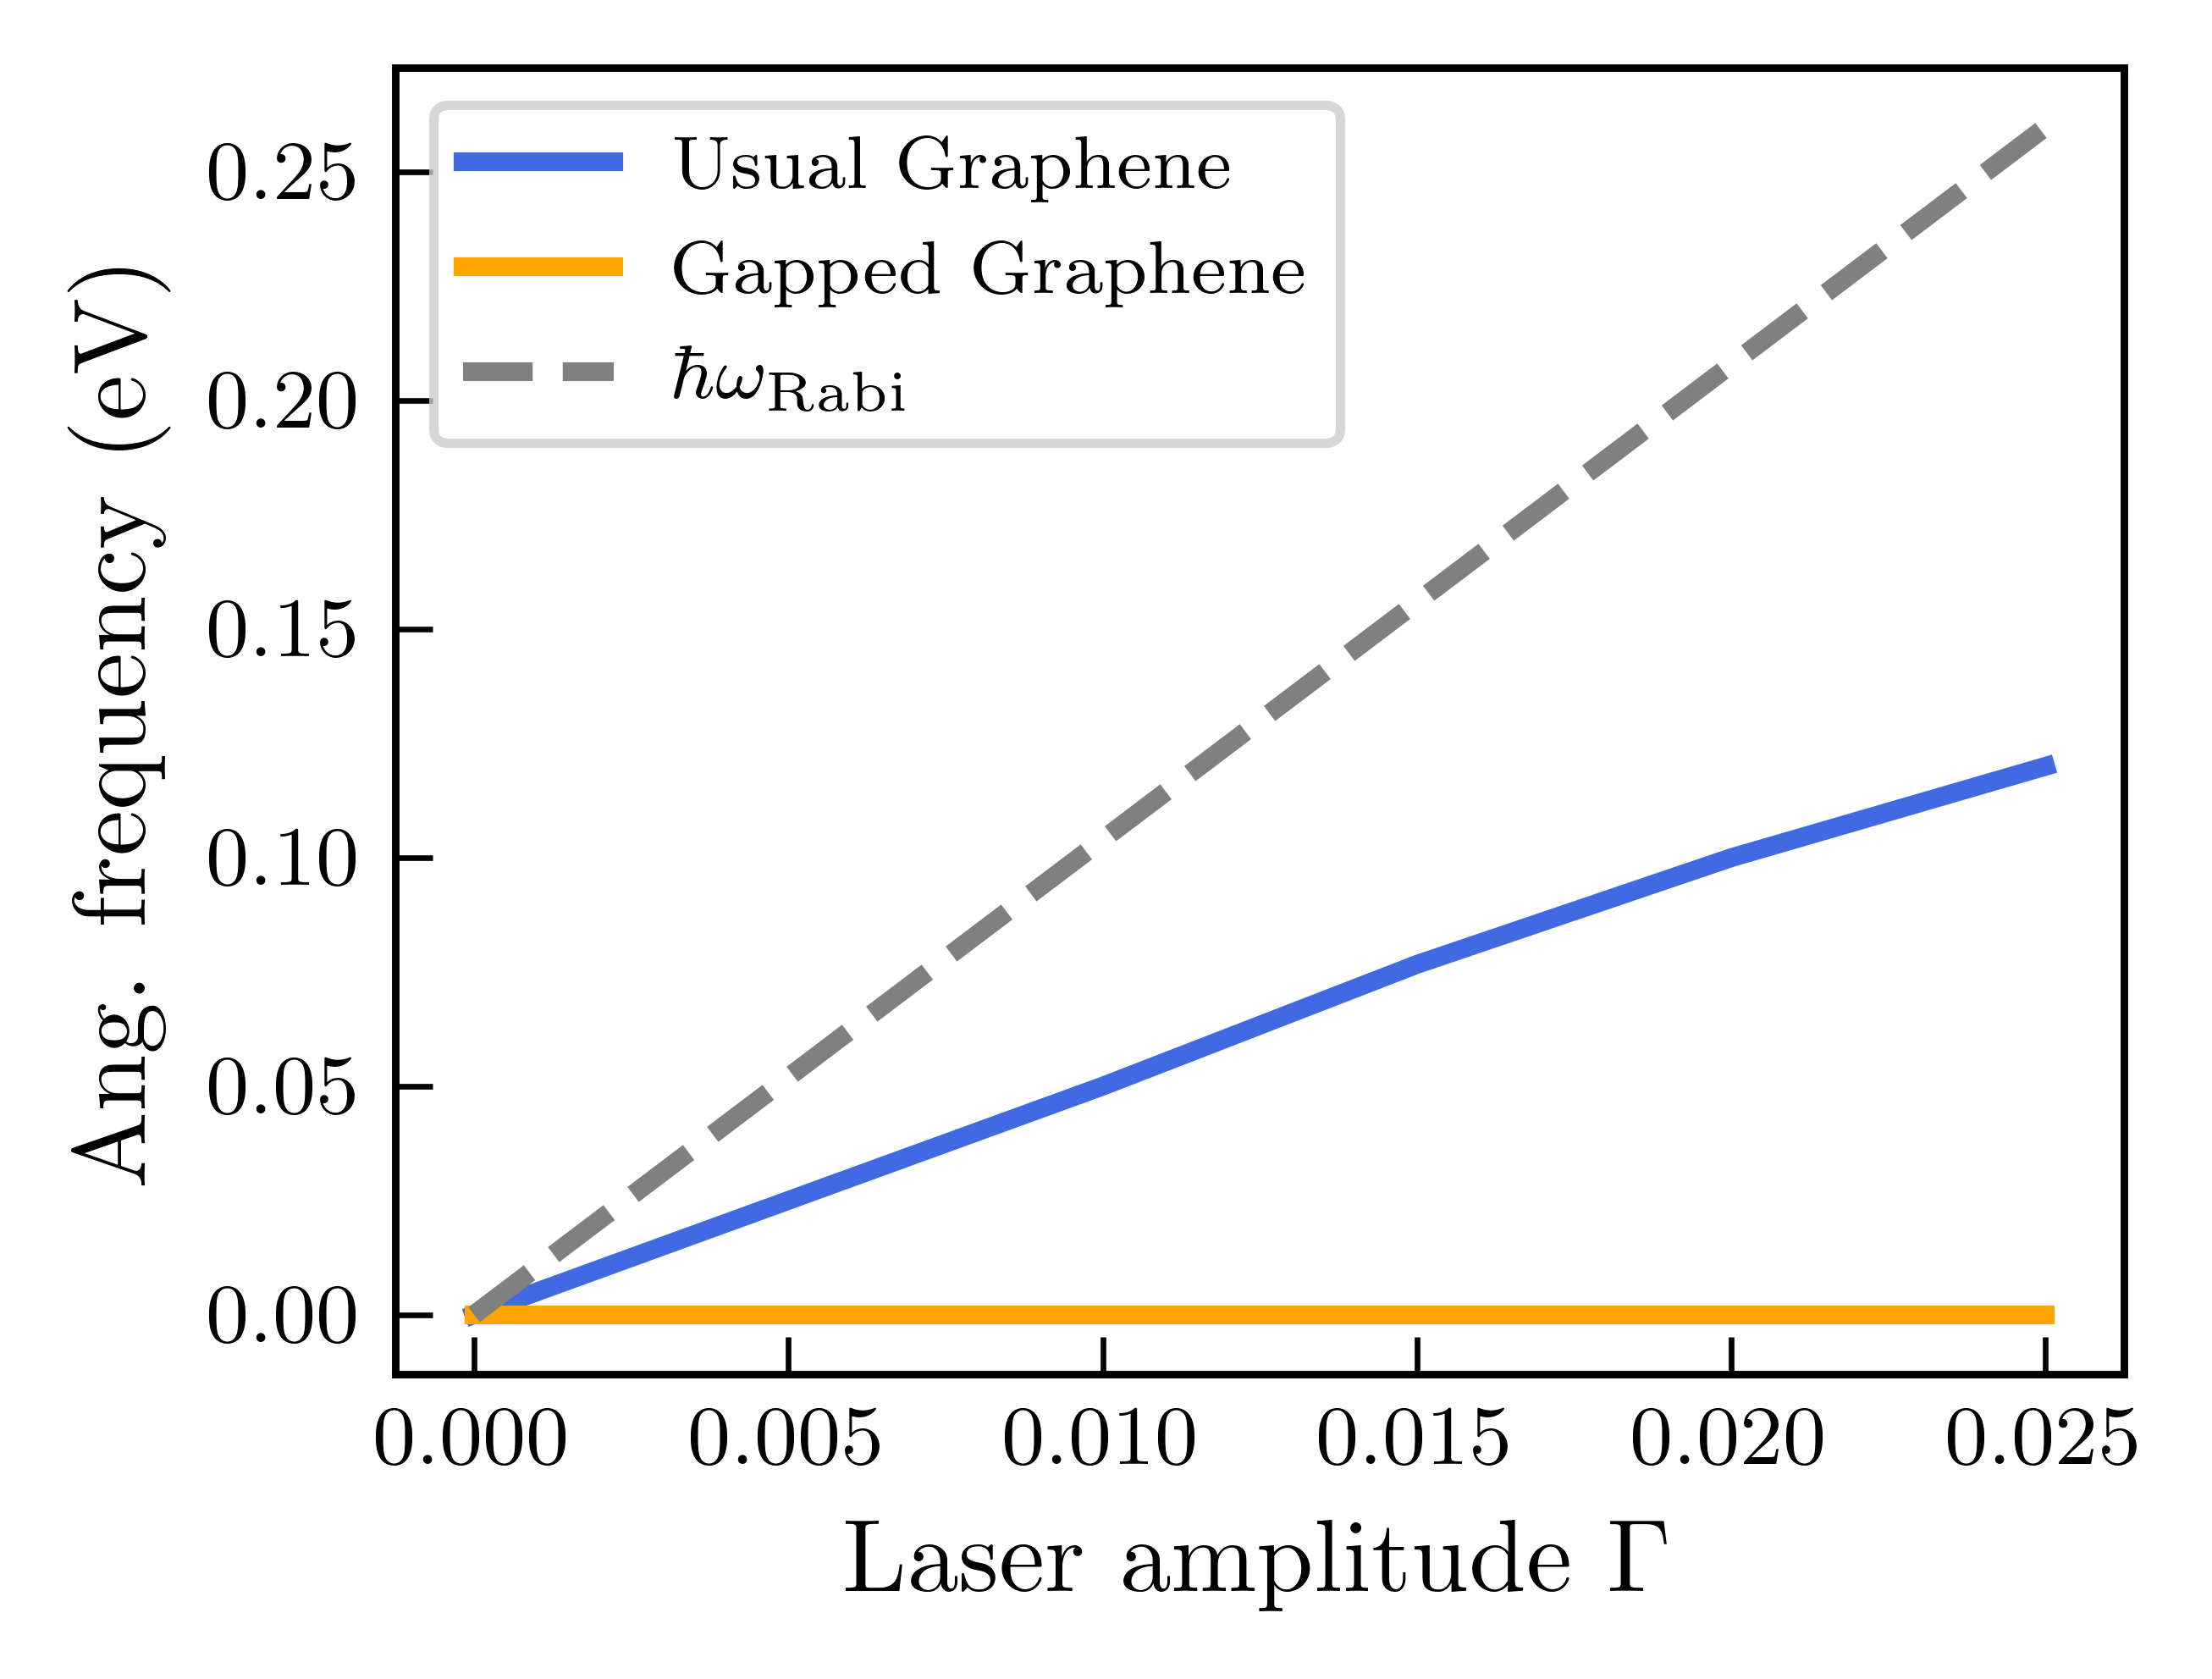

In [68]:

fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
ax.plot(gamma_list, res['char_freq'][:,3]*hbar, ls='-', c='royalblue', marker='.', label='Usual Graphene')
ax.plot(gamma_list, res_hbn['char_freq'][:,3]*hbar, ls='-', marker='.', c='orange', label=f'Gapped Graphene')
ax.plot(gamma_list, rabi_freq*hbar, ls='--', c='grey', label='$\\hbar \\omega_\\mathrm{Rabi}$')
#ax.set_title('Characteristic Frequencies in $E=0.5\\hbar\\omega$')
ax.set_xlabel('Laser amplitude $\\Gamma$')
ax.set_ylabel('Ang. frequency (eV)')
ax.legend()
fig.savefig('Graphs/neq_mass.pdf')